# Scores by SES bucket

Visualizes model scores across **socio-economic status (SES) buckets** by binned
`ses` instead of the raw `social_class` label.

Data: `all_metrics_per_user.csv` (one row per user) for the overall figures and
`all_metrics_topic_0_3.csv` (one row per prompt, two topics) for the per-topic
figures at the end.

**SES buckets** (custom 3-group binning of the 1–10 `ses` scale):

| bucket | ses range | ~ social_class |
|--------|-----------|----------------|
| Low    | 1–3       | low            |
| Middle | 4–7       | middle         |
| High   | 8–10      | upper          |

**Measures**: the human-likeness suite — Human Likeness (`humt`) plus the
`sociot` dimensions Status, Social Distance, Warmth, and Gender — followed by
Helpfulness and Sycophancy (framing / validation / indirectness), the emotion /
linguistic features and the complexity features.

**Marker fill** in the dot plots is driven by the statistical tests in
`../statistical_testing/`: a model's dots are *filled* when the Kruskal-Wallis
omnibus test across social-class groups is significant after Benjamini-Hochberg
FDR correction (`significant_fdr`), and *hollow* otherwise.

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 16,
    "legend.fontsize": 12,
    "legend.title_fontsize": 14,
})

MODEL_IDS = ["qwen-3.5-27B", "llama-3.3-70B", "gemma-4-31B", "gpt-5.5"]

STATS_DIR = "../statistical_testing"   # FDR-corrected group tests
PLOTS_ROOT = "../../plots"             # figures go to <repo>/plots/...

# (column template with {m} = model id, display name)
# Note the column naming differs by family:
#   humt / sociot / helpfulness use the "..._responses_{m}" suffix,
#   sycophancy metrics use "..._{m}".
# The humt + sociot block is the "human likeness" suite (cf. ../human_likeness).
MEASURES = [
    ("humt_responses_{m}",                     "Human Likeness"),
    ("sociot_status_responses_{m}",            "Status"),
    ("sociot_social_distance_responses_{m}",   "Social Distance"),
    ("sociot_warmth_responses_{m}",            "Warmth"),
    ("sociot_gender_responses_{m}",            "Gender"),
    ("normalized_helpfulness_responses_{m}",   "Helpfulness"),
    ("syco_framing_{m}",                       "Sycophancy: Framing"),
    ("syco_validation_{m}",                    "Sycophancy: Validation"),
    ("syco_indirectness_{m}",                  "Sycophancy: Indirectness"),
]

# Emotion / linguistic features from ../emotion/feats.txt, stored as ling_<feature>_<model>.
LING_FEATURES = [
    ("ling_avg_valence_{m}",                 "Valence"),
    ("ling_avg_arousal_{m}",                 "Arousal"),
    ("ling_avg_dominance_{m}",               "Dominance"),
    ("ling_avg_intensity_{m}",               "Emotion Intensity (overall)"),
    ("ling_avg_intensity_anger_{m}",         "Intensity: Anger"),
    ("ling_avg_intensity_anticipation_{m}",  "Intensity: Anticipation"),
    ("ling_avg_intensity_disgust_{m}",       "Intensity: Disgust"),
    ("ling_avg_intensity_fear_{m}",          "Intensity: Fear"),
    ("ling_avg_intensity_joy_{m}",           "Intensity: Joy"),
    ("ling_avg_intensity_sadness_{m}",       "Intensity: Sadness"),
    ("ling_avg_intensity_surprise_{m}",      "Intensity: Surprise"),
    ("ling_avg_intensity_trust_{m}",         "Intensity: Trust"),
    ("ling_sentiment_score_{m}",             "Average Sentiment"),
]

# Complexity features from ../complexity, stored as cplx_<feature>_<model>.
CPLX_FEATURES = [
    ("cplx_syllables_per_word_{m}",                 "Syllables per Word"),
    ("cplx_negations_density_{m}",                  "Negations Density"),
    ("cplx_median_kuperman_age_of_acquisition_{m}", "Median Age of Acquisition"),
    ("cplx_average_age_of_acquisition_{m}",         "Average Age of Acquisition"),
    ("cplx_adversative_connectives_{m}",            "Adversative Connectives"),
]

ALL_MEASURES = MEASURES + LING_FEATURES + CPLX_FEATURES

# SES bucketing --------------------------------------------------------------
# Edit BIN_EDGES / BIN_LABELS to change the buckets.
BIN_EDGES  = [0, 3, 7, 10]          # (0,3] -> Low, (3,7] -> Middle, (7,10] -> High
BIN_LABELS = ["Low", "Middle", "High"]
SES_ORDER  = BIN_LABELS


def add_ses_bucket(df):
    df = df.copy()
    df["ses_bucket"] = pd.cut(df["ses"], bins=BIN_EDGES, labels=BIN_LABELS,
                              include_lowest=True)
    df["ses_bucket"] = pd.Categorical(df["ses_bucket"], categories=SES_ORDER,
                                      ordered=True)
    return df


def shade_buckets(ax, centers, hw=0.5):
    """Alternating bucket backgrounds: light gray / white / light gray.

    `centers` are the bucket x-positions; `hw` is the half-width of each band
    (use hw = spacing/2 so adjacent bands touch with no gap between buckets).
    """
    centers = np.asarray(centers, dtype=float)
    for i, xc in enumerate(centers):
        color = "0.92" if i % 2 == 0 else "white"
        ax.axvspan(xc - hw, xc + hw, color=color, zorder=0)
    ax.set_xlim(centers[0] - hw, centers[-1] + hw)


def dot_handles(colors, labels, markersize=8, filled=True):
    """Legend handles that are plain dots (no connecting/error-bar line).

    `filled=False` gives open (hollow) markers to match unfilled data dots.
    """
    return [Line2D([0], [0], marker="o", linestyle="none",
                   markeredgecolor=c,
                   markerfacecolor=(c if filled else "none"),
                   markersize=markersize, label=l)
            for c, l in zip(colors, labels)]

## Data preparation

The cleaned camera-ready CSVs store the complexity features in their **raw**
units and no longer carry the *adversative connectives* feature. The plots (and
the statistical tests, which are rank-based and therefore unaffected) use the
z-scored features, so the two helpers below

* re-attach `adversative_connectives` per response from
  `../complexity/responses_<model>_complexity.csv` (averaged per user for the
  per-user table, exactly like `aggregate_user.py`), and
* z-score every `cplx_*` column with the population standard deviation, which is
  what `../complexity/normalize_feats.py` did for the earlier, un-cleaned files.

In [2]:
COMPLEXITY_DIR = "../complexity"
# The llama complexity file is named "3.5" although the model is llama-3.3-70B.
COMPLEXITY_FILES = {
    "qwen-3.5-27B":  "responses_qwen-3.5-27B_complexity.csv",
    "llama-3.3-70B": "responses_llama-3.5-70B_complexity.csv",
    "gemma-4-31B":   "responses_gemma-4-31B_complexity.csv",
    "gpt-5.5":       "responses_gpt-5.5_complexity.csv",
}


def load_adversative():
    """{model: Series(response id -> adversative_connectives)}."""
    out = {}
    for model_id, fname in COMPLEXITY_FILES.items():
        d = pd.read_csv(os.path.join(COMPLEXITY_DIR, fname),
                        usecols=["id", "adversative_connectives"])
        out[model_id] = d.set_index("id")["adversative_connectives"]
    return out


def attach_adversative(df, key):
    """Add cplx_adversative_connectives_<model> columns.

    key="id"   -> per-response table, joined directly on the response id
    key="user" -> per-user table, mean over the user's responses
    """
    df = df.copy()
    adv = load_adversative()
    for model_id, series in adv.items():
        col = f"cplx_adversative_connectives_{model_id}"
        if col in df.columns:
            continue
        if key == "id":
            df[col] = df["id"].map(series)
        else:
            per_user = series.groupby(series.index.str.split("p").str[0]).mean()
            df[col] = df["user"].map(per_user)
    return df


def zscore_complexity(df):
    """Standardize every cplx_* column in place: (x - mean) / population std."""
    df = df.copy()
    for col in [c for c in df.columns if c.startswith("cplx_")]:
        s = pd.to_numeric(df[col], errors="coerce")
        sd = s.std(ddof=0)
        if sd and np.isfinite(sd):
            df[col] = (s - s.mean()) / sd
    return df


df = pd.read_csv("all_metrics_per_user.csv", low_memory=False)
df = zscore_complexity(attach_adversative(df, key="user"))
df = add_ses_bucket(df)

print("users per SES bucket:")
print(df["ses_bucket"].value_counts().reindex(SES_ORDER))
print(f"\ntotal users: {len(df)}")

users per SES bucket:
ses_bucket
Low       214
Middle    406
High      112
Name: count, dtype: int64

total users: 732


## Significance (FDR-corrected)

`../statistical_testing/all_group_differences.csv` holds, per model and measure,
the Kruskal-Wallis omnibus test across social-class groups with Benjamini-Hochberg
correction. A measure × model is drawn **filled** only when `significant_fdr` is
true; anything that was not tested is drawn hollow and listed as skipped.

In [3]:
def load_significance(path):
    """Returns (sig: {column -> bool}, p_fdr: {column -> float}, tested bases)."""
    fdr = pd.read_csv(path)
    sig = dict(zip(fdr["measure"], fdr["significant_fdr"].astype(bool)))
    p_fdr = dict(zip(fdr["measure"], fdr["p_omnibus_fdr"]))
    tested = {m[: -(len(mod) + 1)] for m, mod in zip(fdr["measure"], fdr["model"])}
    return sig, p_fdr, tested


SIGNIFICANT, P_FDR, TESTED = load_significance(f"{STATS_DIR}/all_group_differences.csv")

print(f"{sum(SIGNIFICANT.values())} / {len(SIGNIFICANT)} measure x model tests significant after FDR")
untested = ["_".join(t.split("_")[:-1]) for t, _ in ALL_MEASURES
            if "_".join(t.split("_")[:-1]) not in TESTED]
print("not tested (drawn hollow / skipped when saving):", ", ".join(untested) or "none")

31 / 100 measure x model tests significant after FDR
not tested (drawn hollow / skipped when saving): ling_avg_intensity, cplx_median_kuperman_age_of_acquisition


## Mean score per SES bucket

In [4]:
def print_means(data, measures):
    for measure_tpl, m_name in measures:
        print("=" * 60)
        print(m_name)
        print("=" * 60)
        for model_id in MODEL_IDS:
            col = measure_tpl.format(m=model_id)
            if col not in data.columns:
                print(f"  [skip] {model_id}: no column {col}")
                continue
            means = data.groupby("ses_bucket", observed=True)[col].mean().reindex(SES_ORDER).round(4)
            print(f"  {model_id:15s} " + "  ".join(f"{b}={means[b]}" for b in SES_ORDER))
        print()


print_means(df, MEASURES)

Human Likeness
  qwen-3.5-27B    Low=0.0178  Middle=0.0145  High=0.0143
  llama-3.3-70B   Low=0.0192  Middle=0.019  High=0.0172
  gemma-4-31B     Low=0.0171  Middle=0.0183  High=0.0167
  gpt-5.5         Low=0.0223  Middle=0.024  High=0.0197

Status
  qwen-3.5-27B    Low=-0.0536  Middle=-0.0514  High=-0.0523
  llama-3.3-70B   Low=-0.0562  Middle=-0.0561  High=-0.057
  gemma-4-31B     Low=-0.052  Middle=-0.054  High=-0.0533
  gpt-5.5         Low=-0.0594  Middle=-0.0632  High=-0.0603

Social Distance
  qwen-3.5-27B    Low=0.0383  Middle=0.0361  High=0.0367
  llama-3.3-70B   Low=0.0399  Middle=0.0401  High=0.0408
  gemma-4-31B     Low=0.0391  Middle=0.0421  High=0.0388
  gpt-5.5         Low=0.0444  Middle=0.0491  High=0.0439

Warmth
  qwen-3.5-27B    Low=0.0167  Middle=0.0146  High=0.0161
  llama-3.3-70B   Low=0.0148  Middle=0.0112  High=0.0132
  gemma-4-31B     Low=0.0162  Middle=0.0138  High=0.0148
  gpt-5.5         Low=0.0175  Middle=0.0172  High=0.0166

Gender
  qwen-3.5-27B    Low=0.0

## Mean and 95% confidence interval

One panel per measure; models dodged within each SES bucket. Error bars are the
95% CI of the mean (`1.96 * std / sqrt(n)`). Filled dots = significant SES
effect after FDR correction, hollow = not significant.

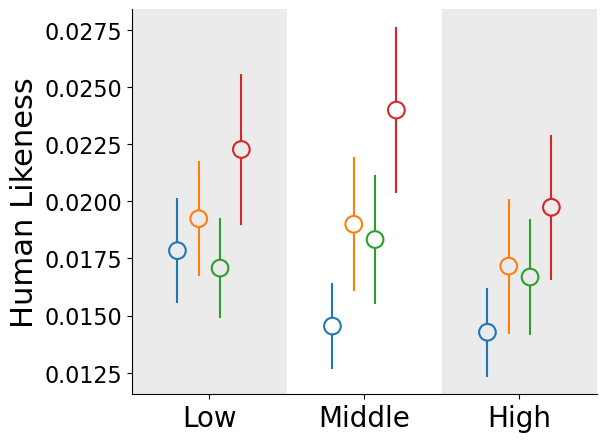

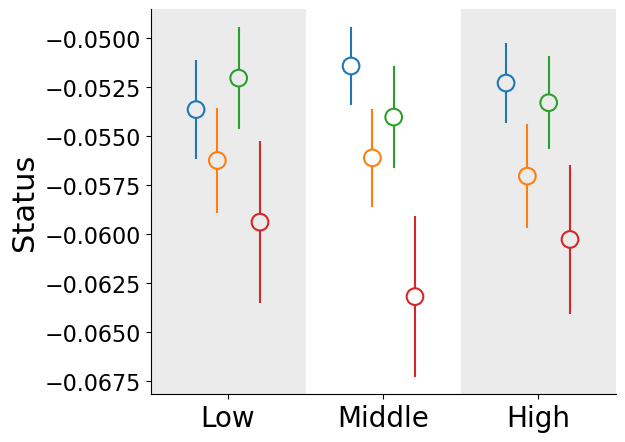

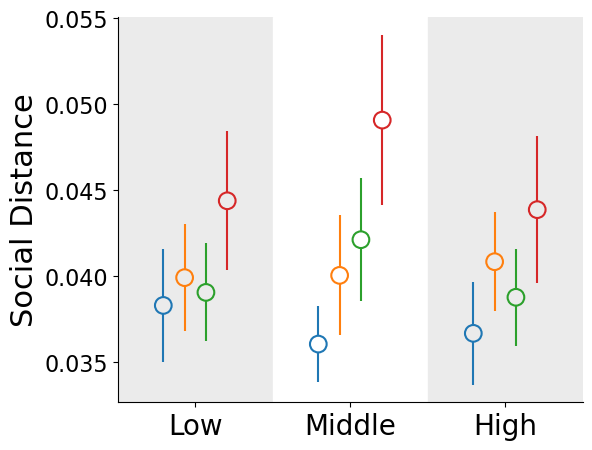

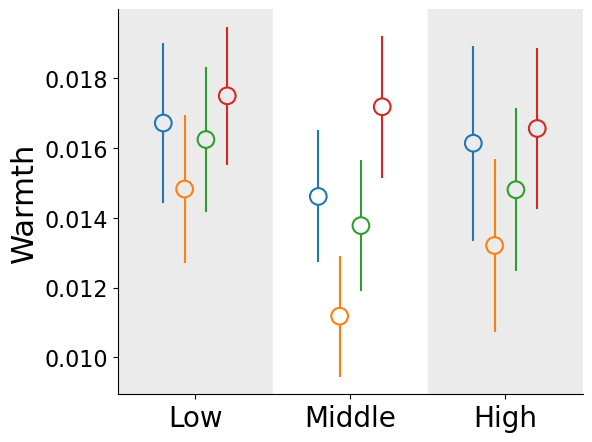

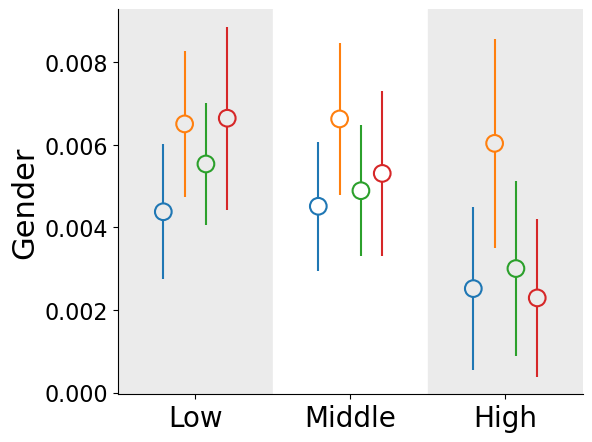

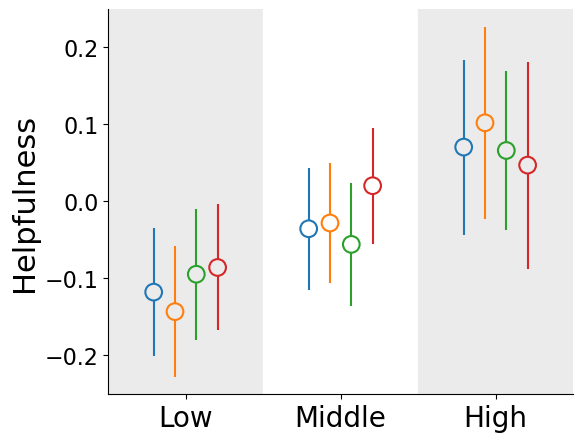

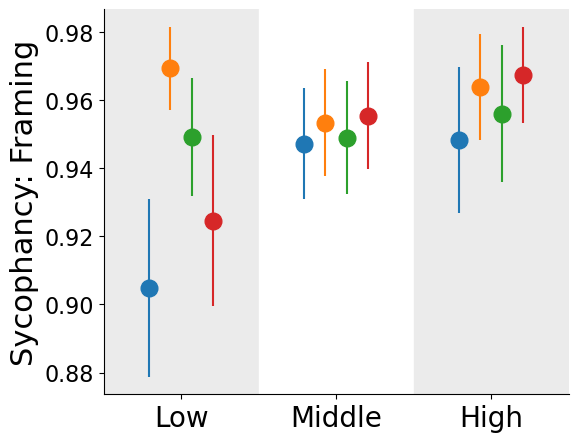

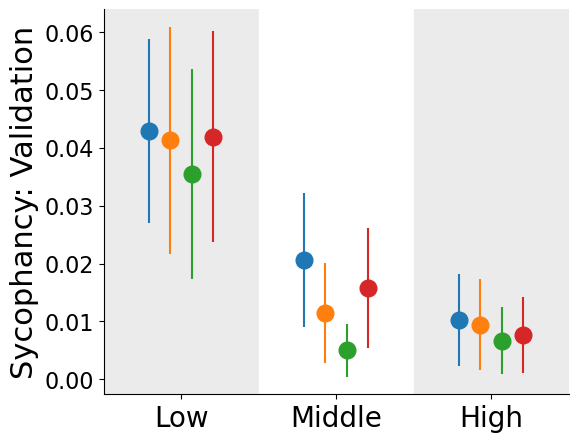

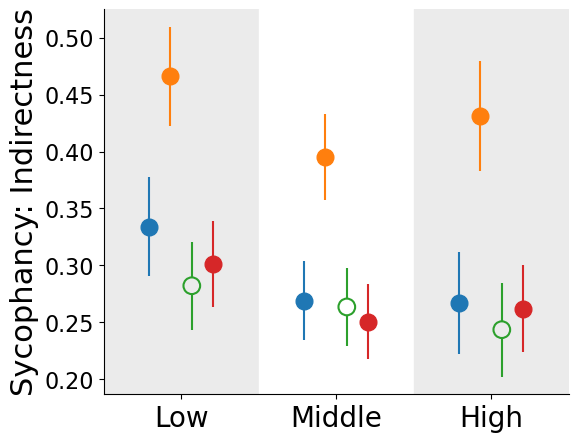

In [5]:
SPACING = 0.9       # distance between bucket centers (< 1 -> less space between buckets)
CLUSTER = 0.55      # fraction of a bucket the per-model dots span (larger -> dots more separated)
MARKER_SIZE = 12    # dot diameter (points); scatter uses MARKER_SIZE**2 for area

# Per-bucket band colors (must match shade_buckets); used as the opaque marker
# face for unfilled dots so the error-bar line is hidden behind each circle
# while the interior still blends with the shaded background.
BAND_FACES = ["0.92" if i % 2 == 0 else "white" for i in range(len(SES_ORDER))]
CYCLE = plt.rcParams["axes.prop_cycle"].by_key()["color"]


def build_stats(data, measure_tpl):
    rows = []
    for model_id in MODEL_IDS:
        col = measure_tpl.format(m=model_id)
        if col not in data.columns:
            continue
        stats = (
            data.groupby("ses_bucket", observed=True)[col]
            .agg(["mean", "std", "count"])
            .reindex(SES_ORDER)
        )
        stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
        for ses, row in stats.iterrows():
            rows.append({"model": model_id, "ses_bucket": ses,
                         "mean": row["mean"], "ci95": row["ci95"]})
    return pd.DataFrame(rows)


def draw_measure(data, measure_tpl, name, significant):
    """Mean ± 95% CI dot plot for one measure. Returns (fig, records) or None.

    A model's dots are FILLED only when `significant` says that measure x model
    has a significant omnibus difference after FDR correction; every other
    case (including a column missing from the stats file) is hollow.
    """
    plot_df = build_stats(data, measure_tpl)
    if plot_df.empty:
        return None
    models = list(plot_df["model"].unique())

    fig, ax = plt.subplots(figsize=(6, 5))
    centers = np.arange(len(SES_ORDER)) * SPACING
    shade_buckets(ax, centers, hw=SPACING / 2)
    dodge_width = CLUSTER * SPACING / max(len(models), 1)

    records = []
    for i, model in enumerate(models):
        col = measure_tpl.format(m=model)
        mdf = plot_df[plot_df["model"] == model].set_index("ses_bucket").reindex(SES_ORDER)
        xpos = centers + (i - len(models) / 2) * dodge_width + dodge_width / 2
        means, yerr = mdf["mean"].values, mdf["ci95"].values
        color = CYCLE[i % len(CYCLE)]
        filled = bool(significant.get(col, False))
        records.append({"model": model, "column": col, "filled": filled})

        if filled:
            ax.errorbar(xpos, means, yerr=yerr, fmt="o", color=color,
                        markersize=MARKER_SIZE, capsize=0)
        else:
            # error-bar line first, then an opaque-faced ring on top so the
            # line is hidden inside each (still empty-looking) circle
            ax.errorbar(xpos, means, yerr=yerr, fmt="none", ecolor=color,
                        capsize=0, zorder=2)
            ax.scatter(xpos, means, s=MARKER_SIZE ** 2, facecolors=BAND_FACES,
                       edgecolors=color, linewidths=1.5, zorder=3)

    ax.set_xticks(centers)
    ax.set_xticklabels(SES_ORDER)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylabel(name)
    if name == "Dominance":               # 2-decimal y ticks (0.575 -> 0.58)
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.02))
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    # ax.legend(handles=dot_handles(colors, models, markersize=MARKER_SIZE, filled=filled),
    #           loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2)
    # (no tight_layout: the saved PDFs are cropped with bbox_inches="tight")
    return fig, records


def base_name(measure_tpl):
    """'syco_framing_{m}' -> 'syco_framing' (used for file names)."""
    return "_".join(measure_tpl.split("_")[:-1])


def dot_plots(data, measures, significant, p_fdr, tested, outdir, show=True):
    """Draw + save one dot plot per tested measure; return the fill manifest."""
    os.makedirs(outdir, exist_ok=True)
    manifest, skipped = [], []
    for measure_tpl, name in measures:
        base = base_name(measure_tpl)
        drawn = draw_measure(data, measure_tpl, name, significant) if base in tested else None
        if drawn is None:
            skipped.append(base)
            continue
        fig, records = drawn
        for rec in records:
            manifest.append({
                "measure": name, "column": rec["column"], "model": rec["model"],
                "p_omnibus_fdr": p_fdr.get(rec["column"], np.nan),
                "significant_fdr": rec["filled"],
                "marker": "filled" if rec["filled"] else "hollow",
            })
        fig.savefig(os.path.join(outdir, f"ses_{base}.pdf"), dpi=600,
                    bbox_inches="tight", format="pdf")
        if show:
            plt.show()
        else:
            plt.close(fig)
    if skipped:
        print("skipped (not tested / no data):", ", ".join(skipped))
    return pd.DataFrame(manifest)


OVERALL_DIR = f"{PLOTS_ROOT}/overall"
manifest_overall = dot_plots(df, MEASURES, SIGNIFICANT, P_FDR, TESTED, OVERALL_DIR)

## Score distributions (violin plots)

Full distribution of scores per SES bucket, split by model.

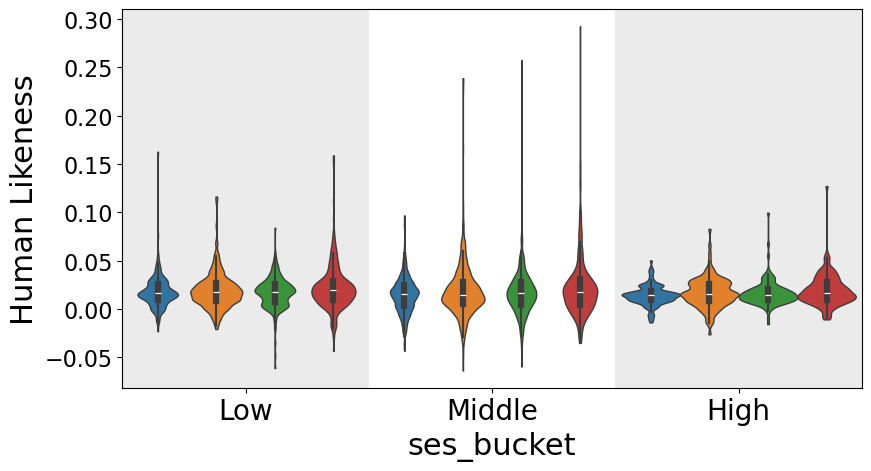

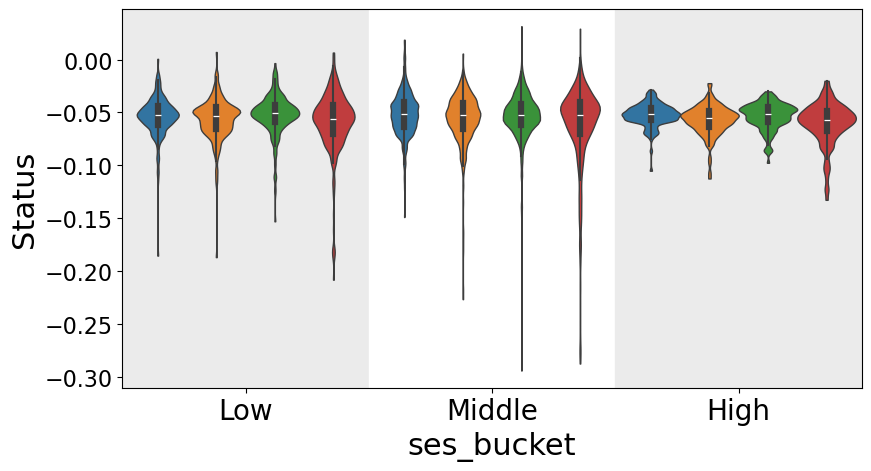

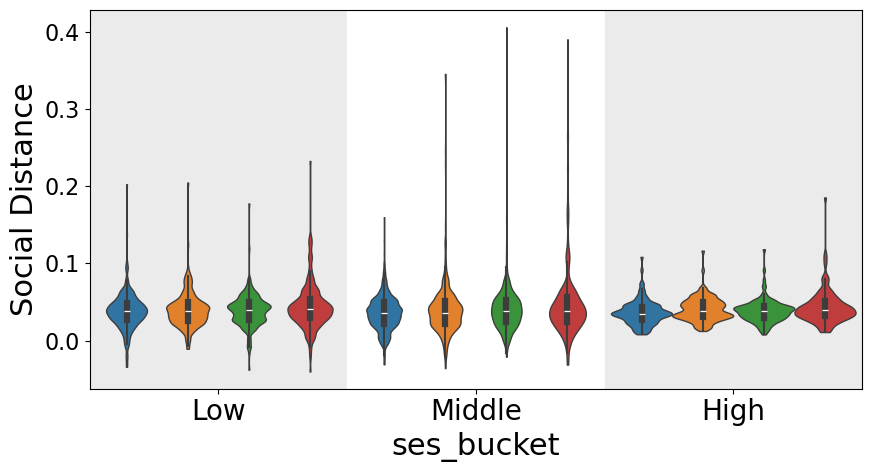

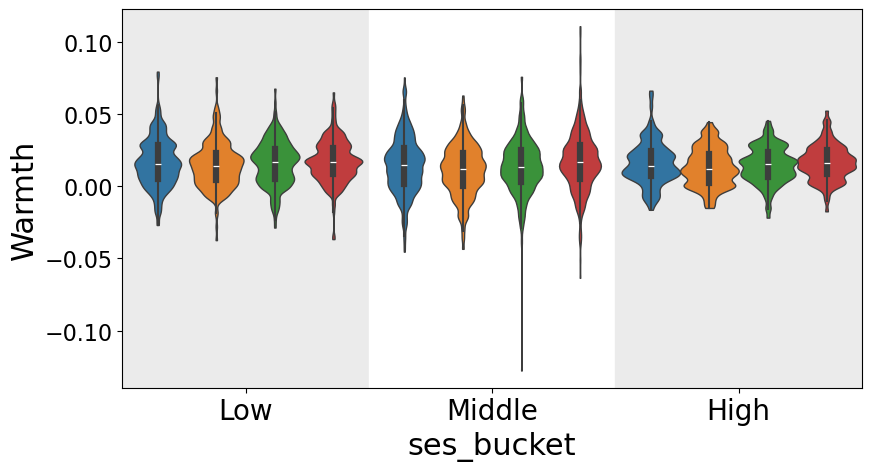

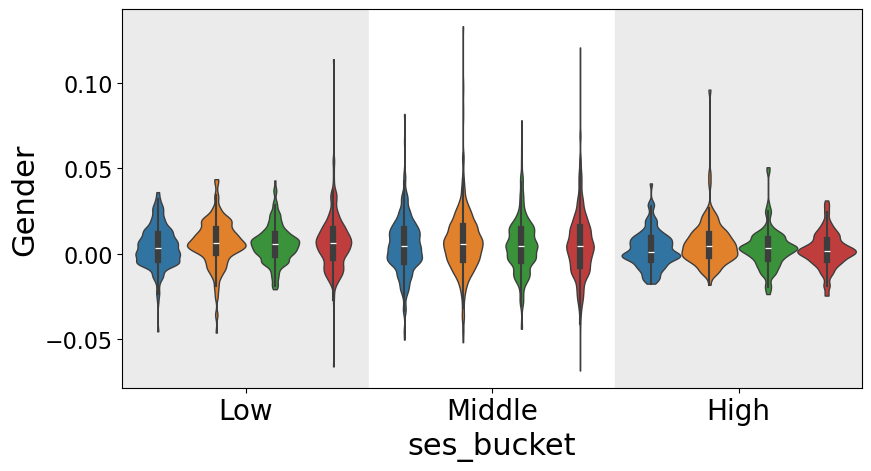

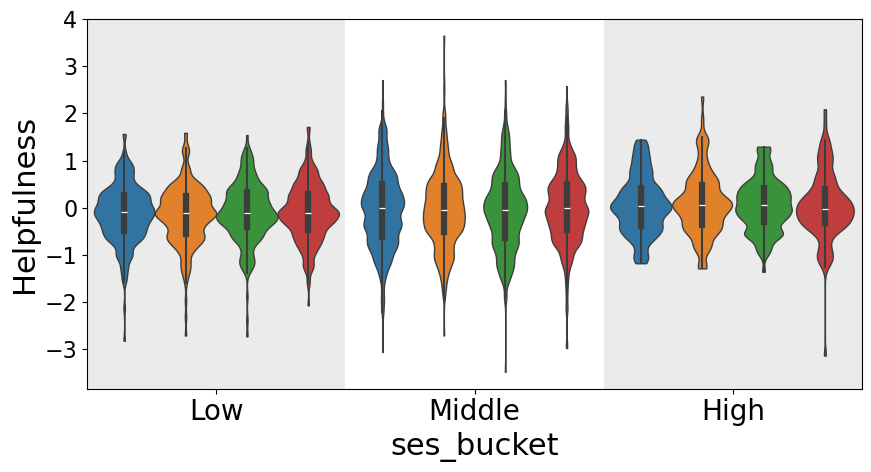

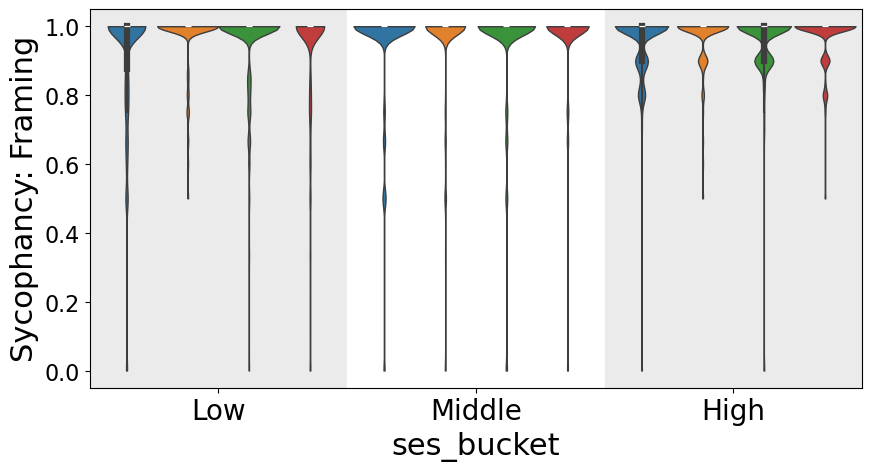

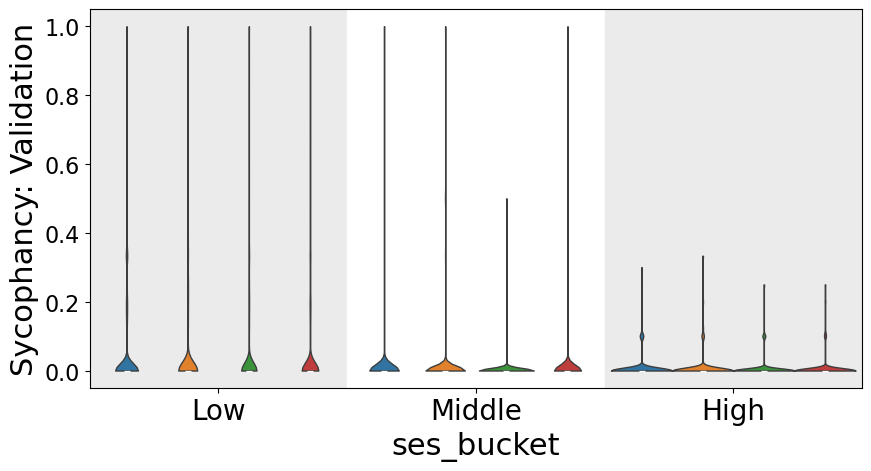

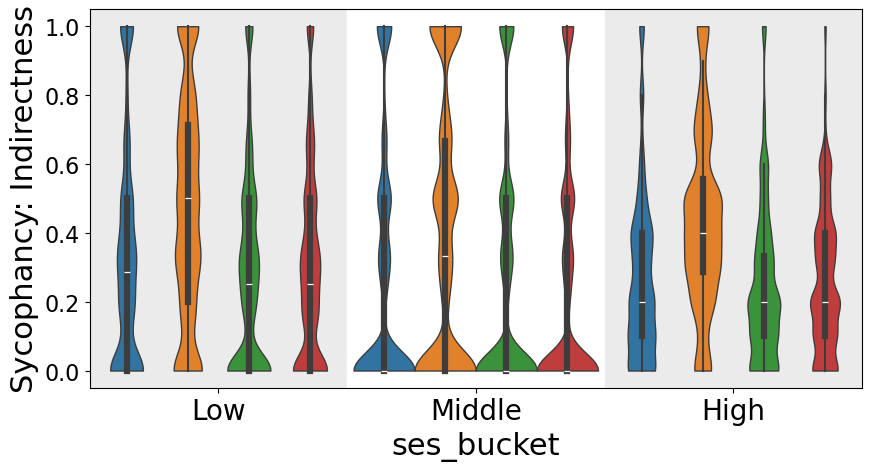

In [6]:
def violin_plots(data, measures):
    for measure_tpl, m_name in measures:
        parts = []
        for model_id in MODEL_IDS:
            col = measure_tpl.format(m=model_id)
            if col not in data.columns:
                continue
            temp = data[["ses_bucket", col]].rename(columns={col: "score"}).copy()
            temp["model"] = model_id
            parts.append(temp)
        if not parts:
            continue

        plot_df = pd.concat(parts, ignore_index=True).dropna(subset=["score"])

        fig, ax = plt.subplots(figsize=(9, 5))
        shade_buckets(ax, np.arange(len(SES_ORDER)))
        sns.violinplot(
            data=plot_df, x="ses_bucket", y="score", hue="model",
            order=SES_ORDER, dodge=True, cut=0, inner="box",
            bw_adjust=0.5, linewidth=1, width=0.95, legend=False, ax=ax,
        )

        ax.set_ylabel(m_name)
        plt.tight_layout()
        plt.show()


violin_plots(df, MEASURES)

# Emotion / linguistic features by SES bucket

The 13 linguistic features from `../emotion/feats.txt`, stored as
`ling_<feature>_<model>` columns: the VAD affect dimensions (valence, arousal,
dominance), NRC emotion intensities (anger, anticipation, disgust, fear, joy,
sadness, surprise, trust), an overall emotion intensity, and an overall
sentiment score. Same three views as above (means table, mean ± 95% CI dot
plots, violin distributions).

In [7]:
print_means(df, LING_FEATURES)

Valence
  qwen-3.5-27B    Low=0.6698  Middle=0.6725  High=0.6772
  llama-3.3-70B   Low=0.6768  Middle=0.6836  High=0.6847
  gemma-4-31B     Low=0.6486  Middle=0.6533  High=0.6538
  gpt-5.5         Low=0.6098  Middle=0.6213  High=0.6237

Arousal
  qwen-3.5-27B    Low=0.5233  Middle=0.5137  High=0.5338
  llama-3.3-70B   Low=0.4631  Middle=0.4529  High=0.4711
  gemma-4-31B     Low=0.3611  Middle=0.3556  High=0.3669
  gpt-5.5         Low=0.4381  Middle=0.4362  High=0.4525

Dominance
  qwen-3.5-27B    Low=0.5425  Middle=0.5556  High=0.5753
  llama-3.3-70B   Low=0.5429  Middle=0.5661  High=0.5889
  gemma-4-31B     Low=0.4835  Middle=0.4937  High=0.5028
  gpt-5.5         Low=0.4609  Middle=0.4905  High=0.5125

Emotion Intensity (overall)
  [skip] qwen-3.5-27B: no column ling_avg_intensity_qwen-3.5-27B
  [skip] llama-3.3-70B: no column ling_avg_intensity_llama-3.3-70B
  [skip] gemma-4-31B: no column ling_avg_intensity_gemma-4-31B
  [skip] gpt-5.5: no column ling_avg_intensity_gpt-5.5

Intensit

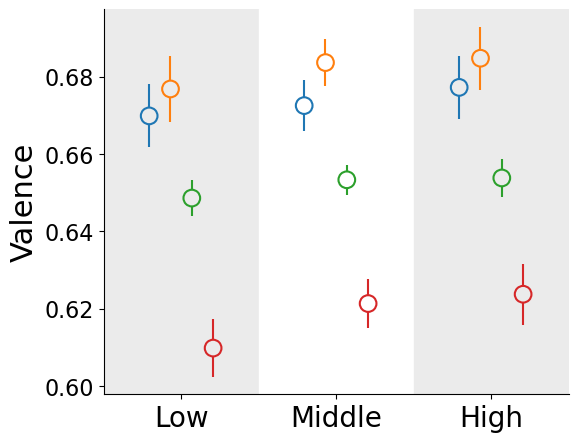

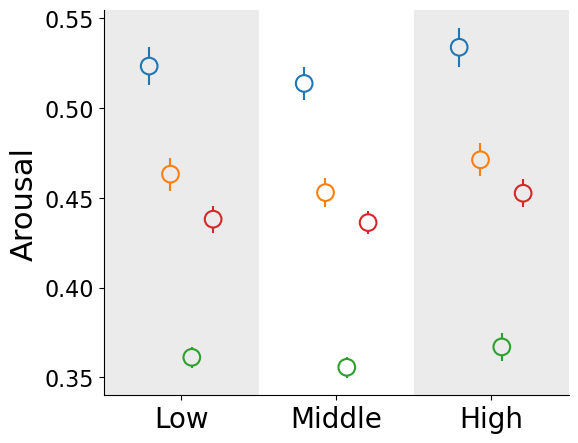

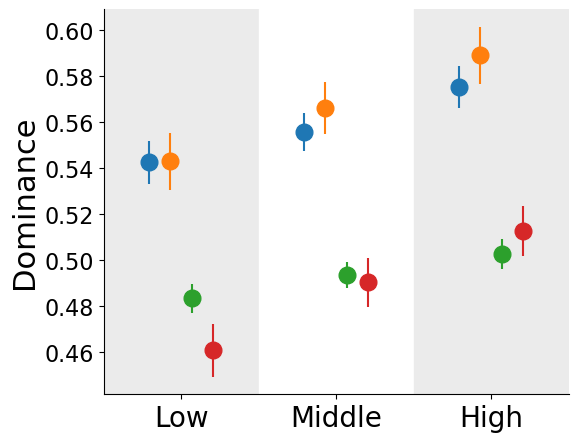

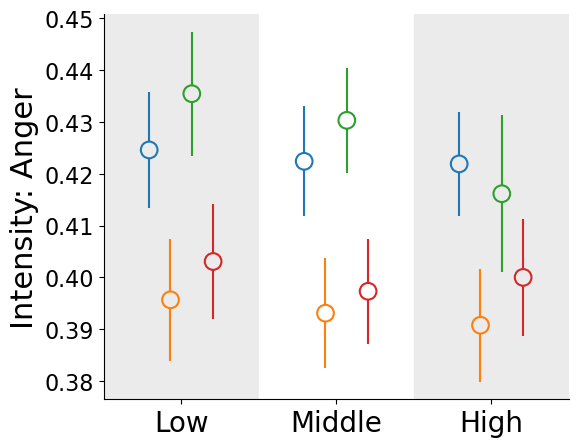

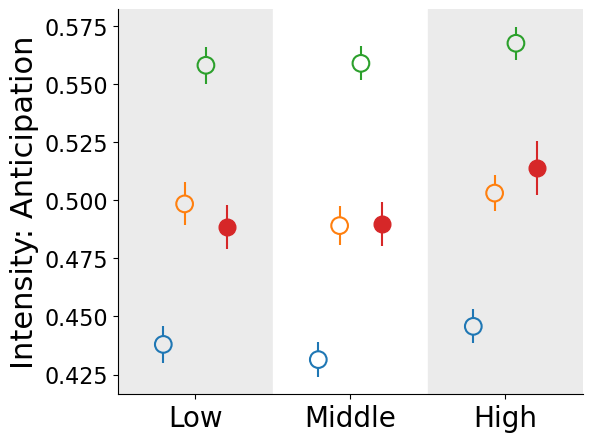

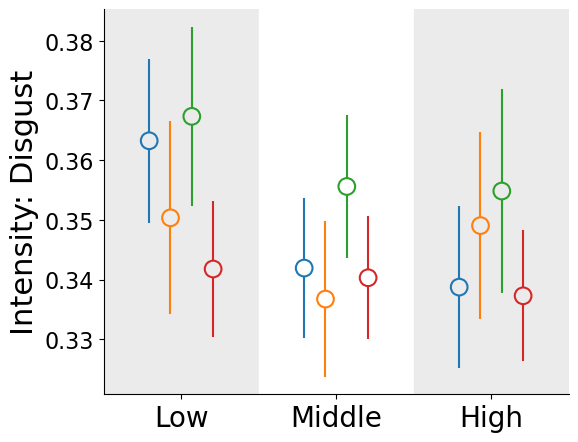

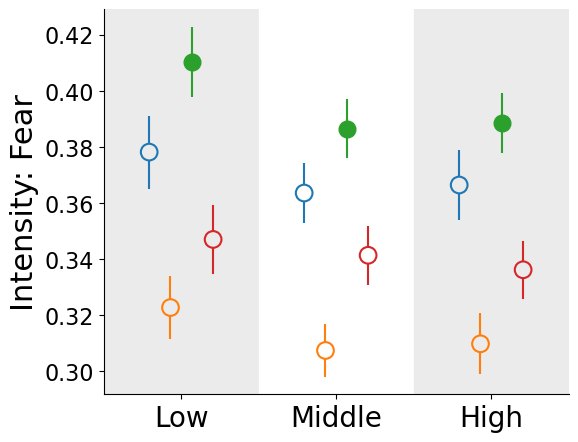

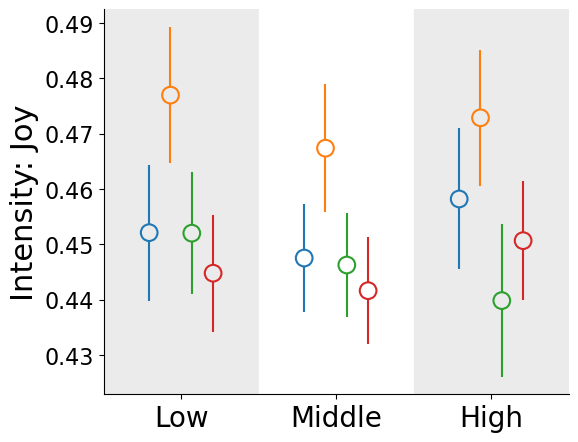

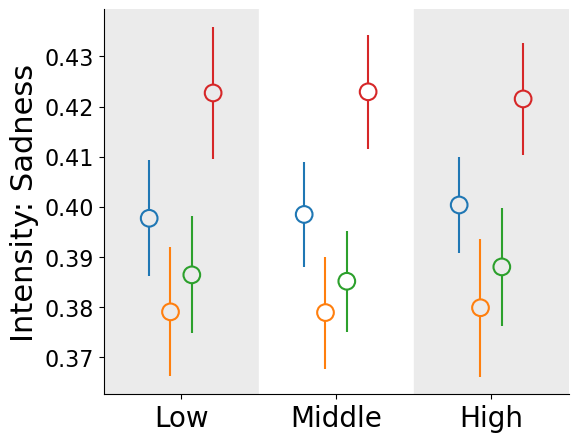

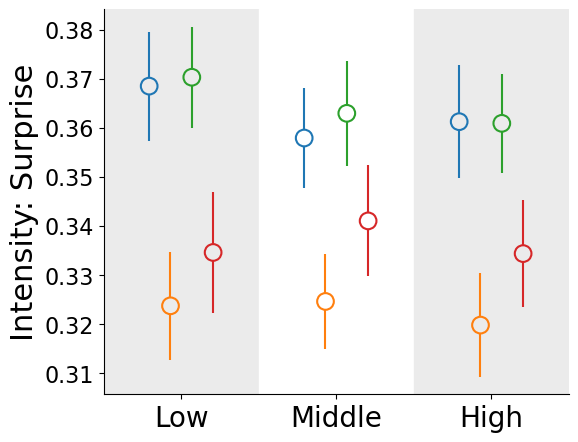

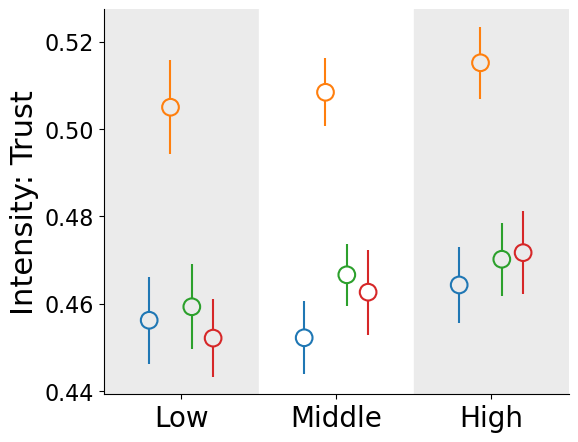

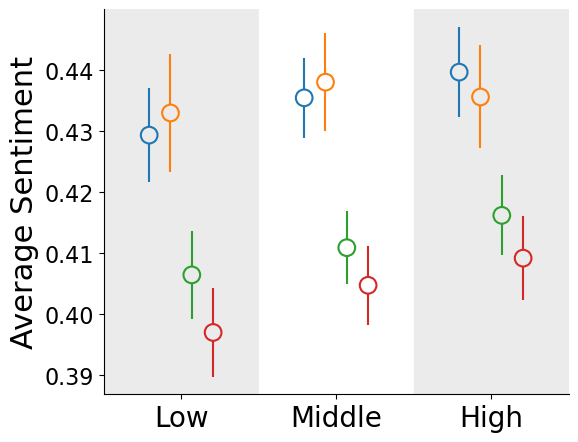

skipped (not tested / no data): ling_avg_intensity


In [8]:
### Linguistic features: mean and 95% CI ###
manifest_overall = pd.concat(
    [manifest_overall, dot_plots(df, LING_FEATURES, SIGNIFICANT, P_FDR, TESTED, OVERALL_DIR)],
    ignore_index=True,
)

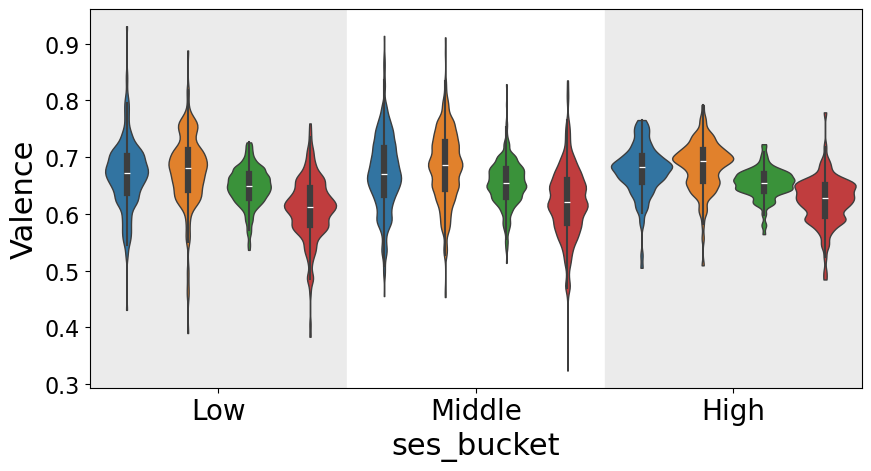

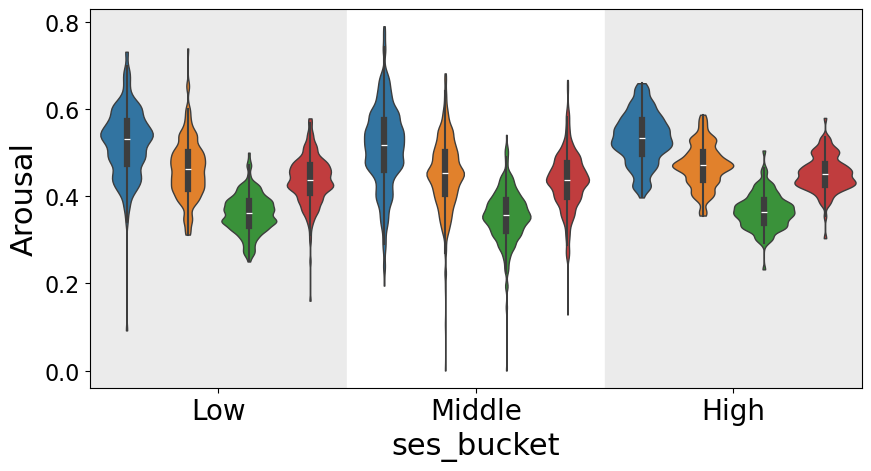

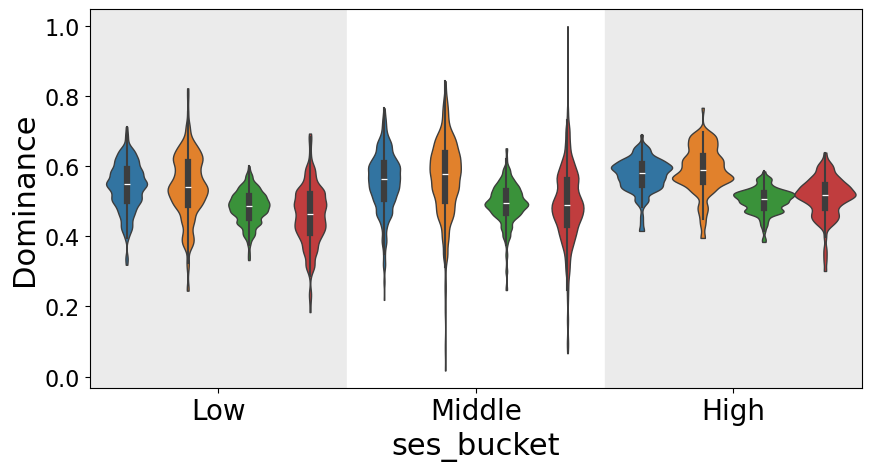

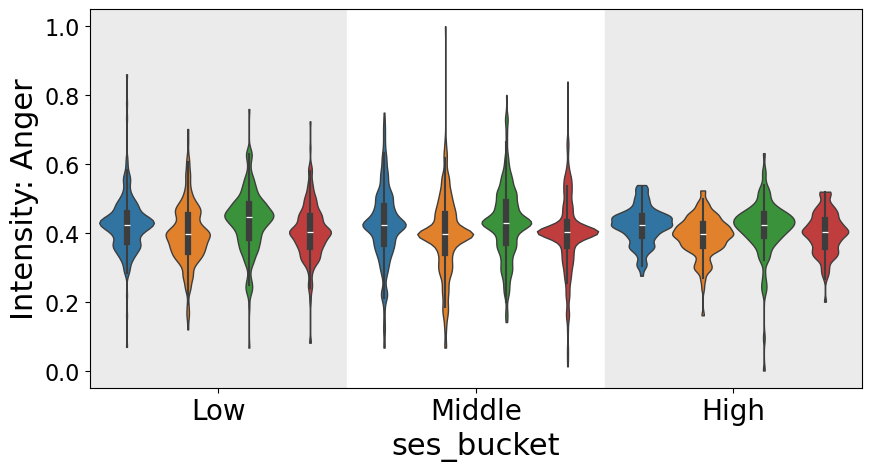

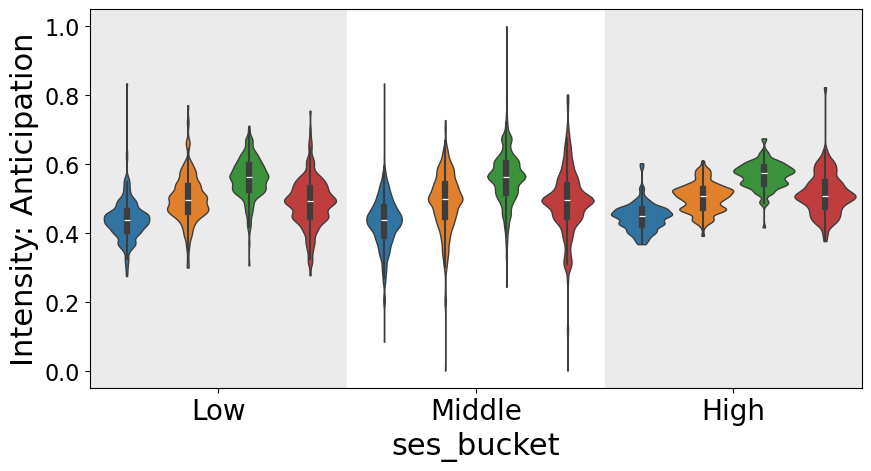

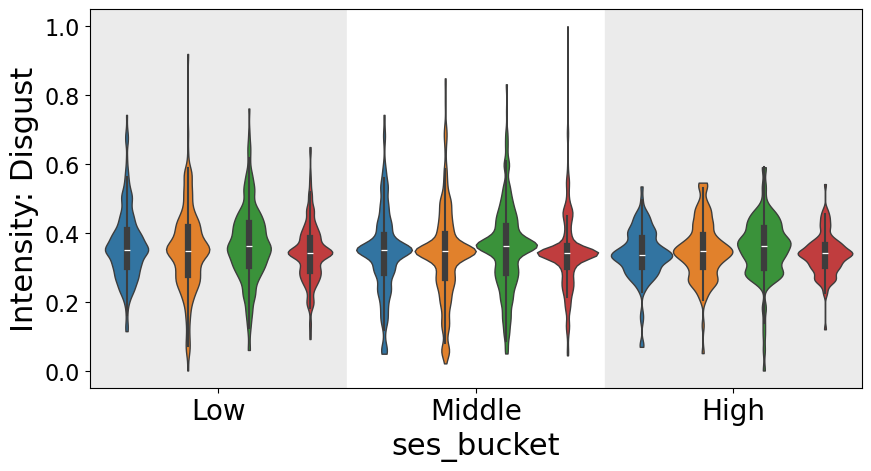

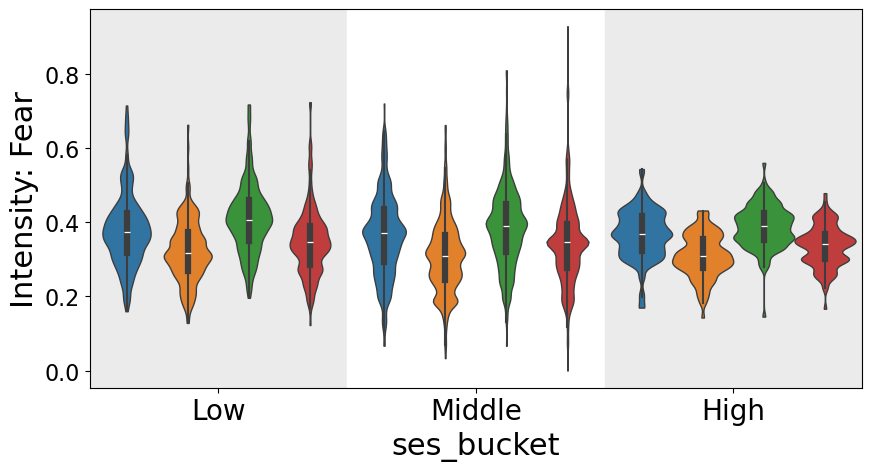

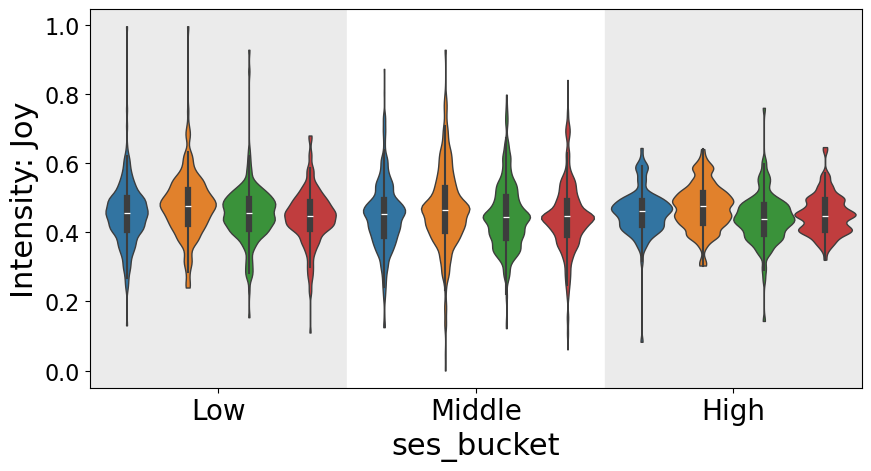

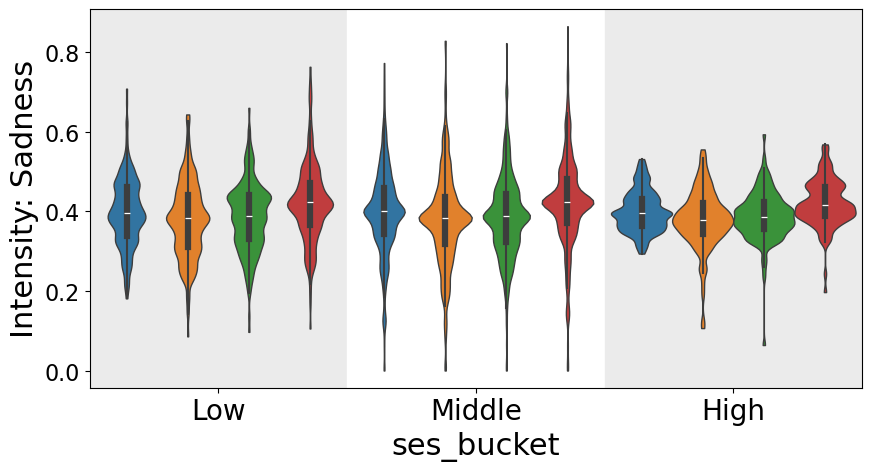

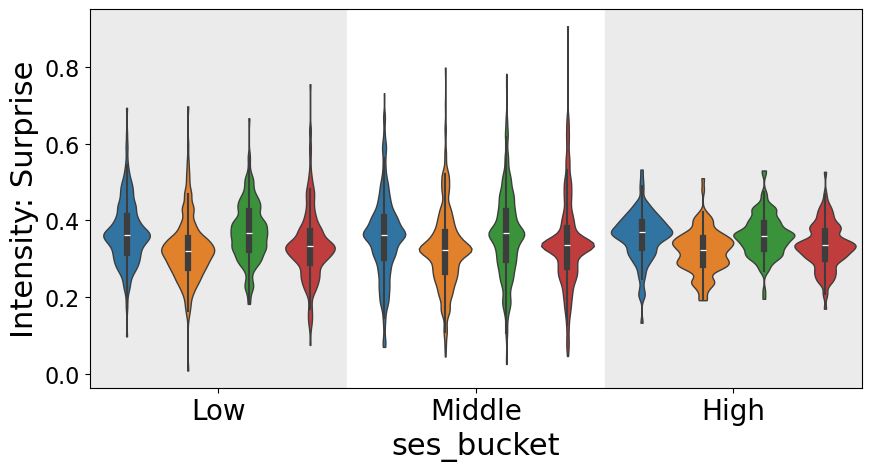

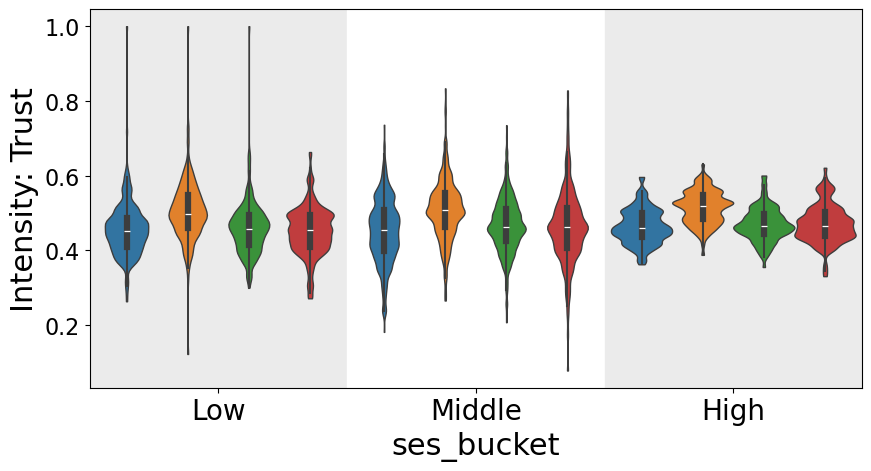

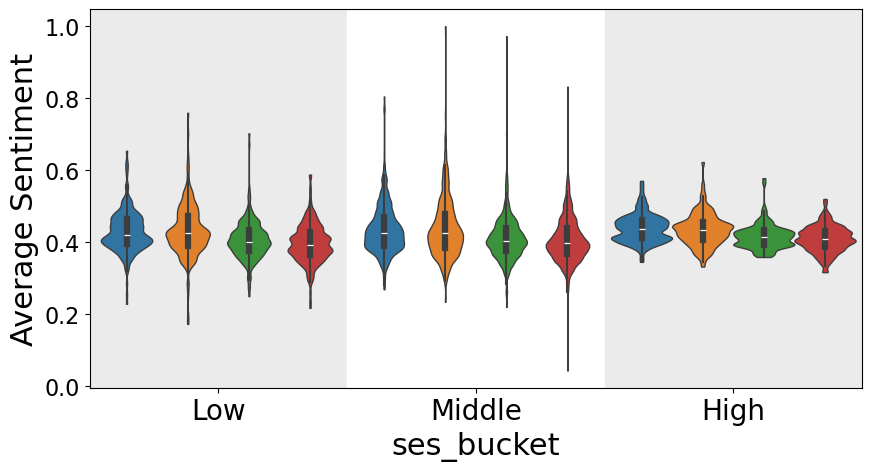

In [9]:
### Linguistic features: score distributions (violin plots) ###
violin_plots(df, LING_FEATURES)

# Complexity features by SES bucket

The complexity features from `../complexity`, stored as `cplx_<feature>_<model>`
columns (z-scored, see *Data preparation*): syllables per word, negations
density, the average Kuperman age-of-acquisition and adversative-connective
density. (The median age-of-acquisition is listed for completeness but is not
part of the cleaned data or the statistical tests, so it is skipped.) Same three
views as the sections above.

In [10]:
print_means(df, CPLX_FEATURES)

Syllables per Word
  qwen-3.5-27B    Low=-0.1653  Middle=0.0118  High=0.2729
  llama-3.3-70B   Low=-0.169  Middle=0.0244  High=0.2345
  gemma-4-31B     Low=-0.1607  Middle=0.0297  High=0.1995
  gpt-5.5         Low=-0.1819  Middle=0.037  High=0.2147

Negations Density
  qwen-3.5-27B    Low=0.0526  Middle=-0.0213  High=-0.0233
  llama-3.3-70B   Low=-0.0484  Middle=0.0344  High=-0.0323
  gemma-4-31B     Low=0.0352  Middle=-0.0307  High=0.0441
  gpt-5.5         Low=0.0819  Middle=-0.0524  High=0.0328

Median Age of Acquisition
  [skip] qwen-3.5-27B: no column cplx_median_kuperman_age_of_acquisition_qwen-3.5-27B
  [skip] llama-3.3-70B: no column cplx_median_kuperman_age_of_acquisition_llama-3.3-70B
  [skip] gemma-4-31B: no column cplx_median_kuperman_age_of_acquisition_gemma-4-31B
  [skip] gpt-5.5: no column cplx_median_kuperman_age_of_acquisition_gpt-5.5

Average Age of Acquisition
  qwen-3.5-27B    Low=-0.2187  Middle=0.0455  High=0.253
  llama-3.3-70B   Low=-0.1517  Middle=0.0202  High=0

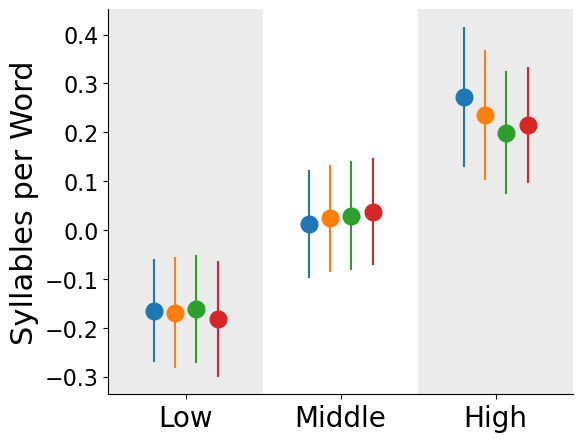

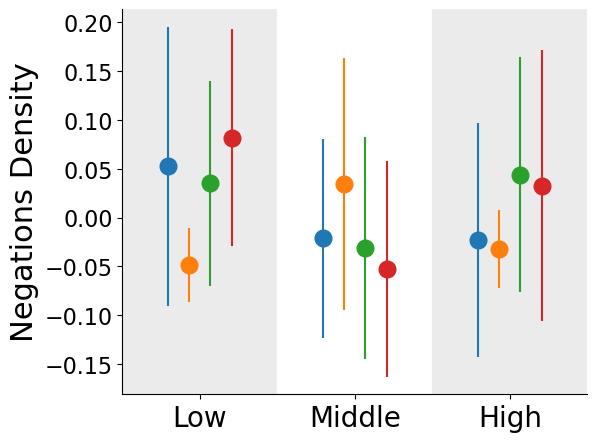

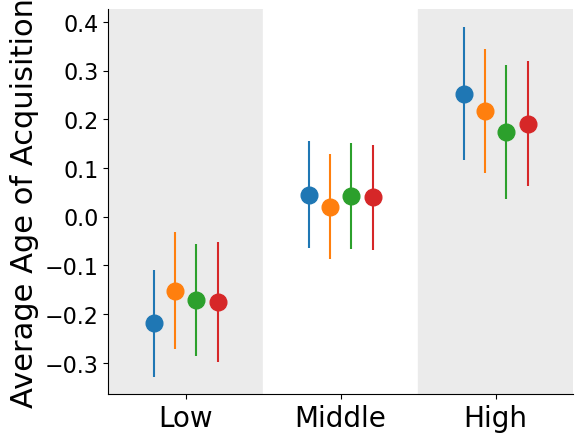

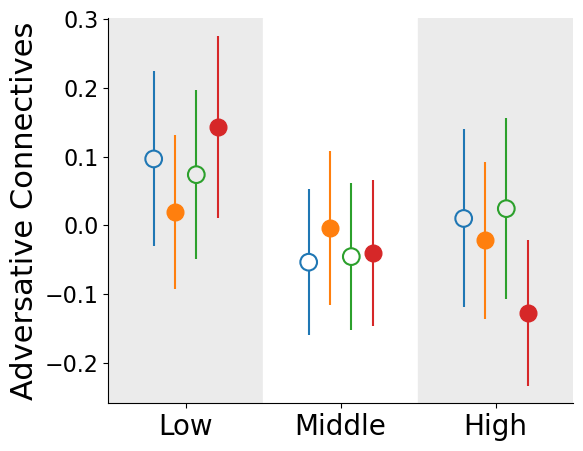

skipped (not tested / no data): cplx_median_kuperman_age_of_acquisition
25 figures -> ../../plots/overall/  (31 filled / 100 dots)


In [11]:
### Complexity features: mean and 95% CI ###
manifest_overall = pd.concat(
    [manifest_overall, dot_plots(df, CPLX_FEATURES, SIGNIFICANT, P_FDR, TESTED, OVERALL_DIR)],
    ignore_index=True,
)
manifest_overall.to_csv(f"{OVERALL_DIR}/significance_manifest.csv", index=False)
print(f"{manifest_overall['measure'].nunique()} figures -> {OVERALL_DIR}/  "
      f"({int(manifest_overall.significant_fdr.sum())} filled / {len(manifest_overall)} dots)")

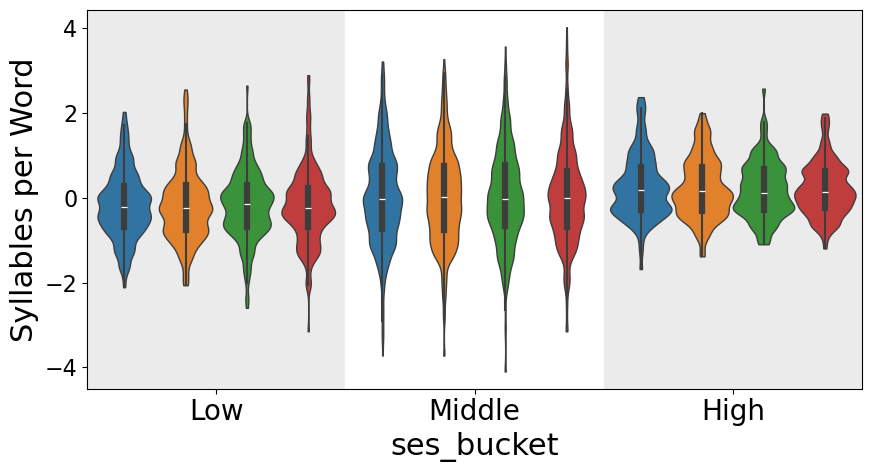

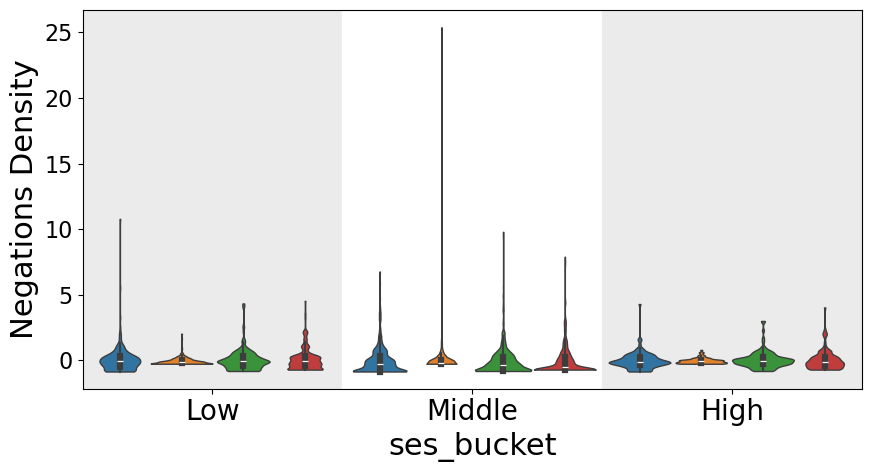

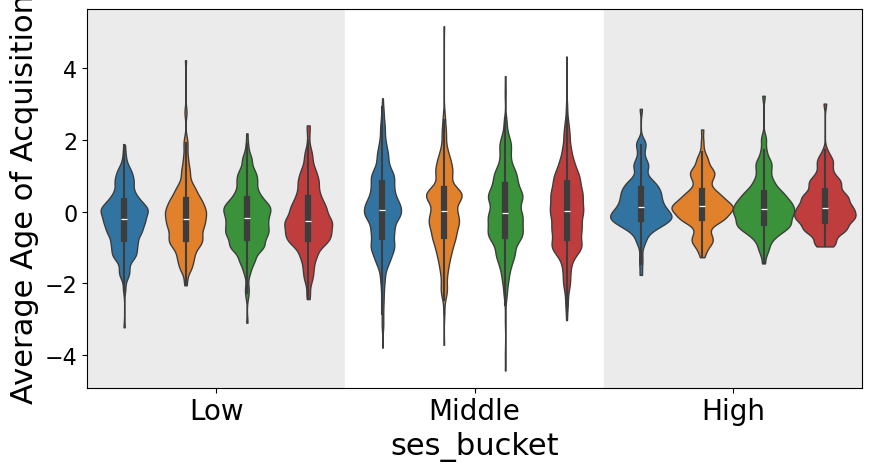

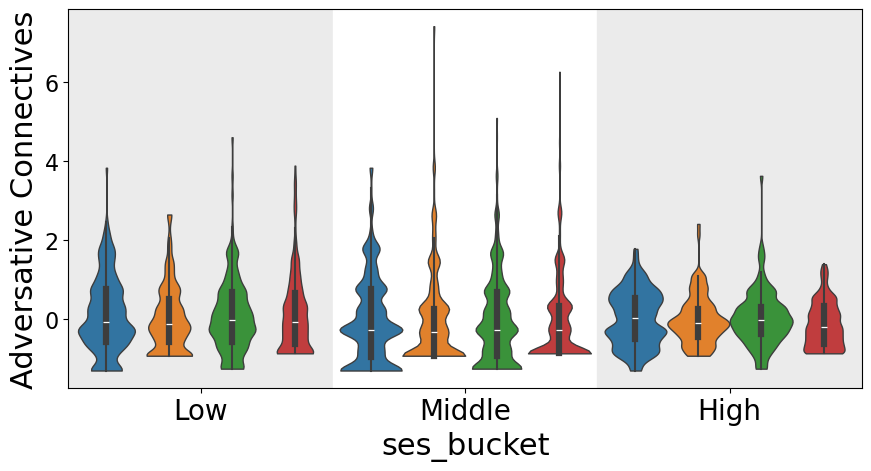

In [12]:
### Complexity features: score distributions (violin plots) ###
violin_plots(df, CPLX_FEATURES)

# SES sensitivity summary (High − Low)

A single overview across **all** measures at once. For each measure and model we
take the High-SES bucket mean minus the Low-SES bucket mean, divided by that
column's overall standard deviation — so the effect is expressed in **standard
deviations** and every measure (regardless of its raw scale) sits on one
comparable axis. Measures are sorted by mean absolute effect, so the scores that
depend most on SES rise to the top; bars to the right mean higher for High-SES
users, to the left mean higher for Low-SES users.

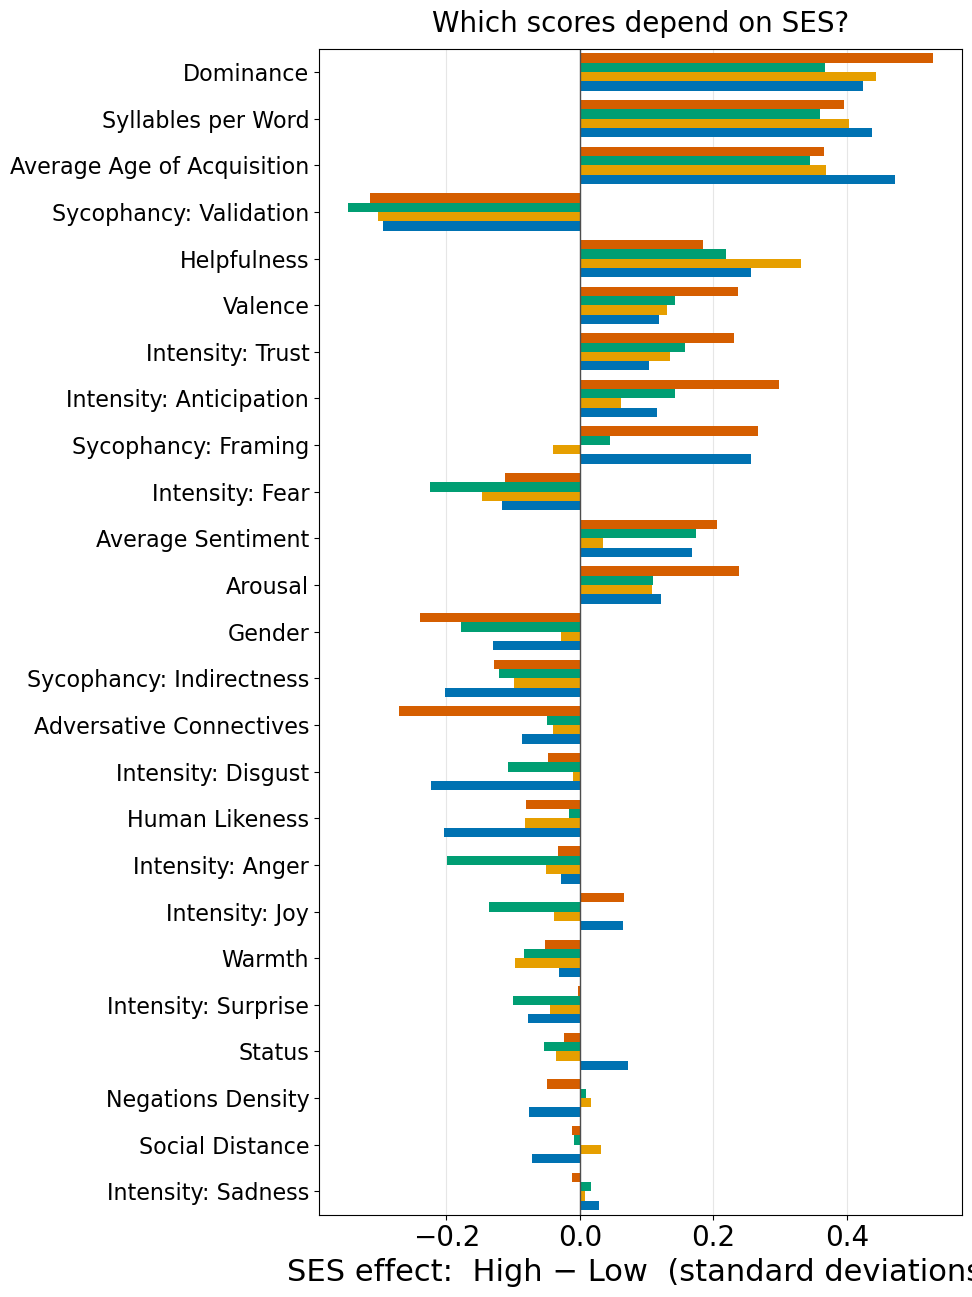

Standardized SES effect (High - Low, in SDs), most sensitive first:

model                       qwen-3.5-27B  llama-3.3-70B  gemma-4-31B  gpt-5.5
measure                                                                      
Dominance                          0.424          0.444        0.367    0.529
Syllables per Word                 0.438          0.403        0.360    0.396
Average Age of Acquisition         0.471          0.369        0.345    0.366
Sycophancy: Validation            -0.295         -0.303       -0.347   -0.314
Helpfulness                        0.256          0.331        0.219    0.184
Valence                            0.118          0.130        0.143    0.236
Intensity: Trust                   0.104          0.134        0.157    0.230
Intensity: Anticipation            0.116          0.061        0.143    0.298
Sycophancy: Framing                0.256         -0.040        0.045    0.267
Intensity: Fear                   -0.117         -0.147       -0.224   -0

In [13]:
# Standardized SES effect: (mean_High - mean_Low) / std_overall, per measure & model.
# Dividing by each column's overall std puts every measure on a common scale
# (units = standard deviations), so measures with very different raw ranges
# (e.g. humt ~0.02 vs. sentiment ~0.4) become directly comparable and rankable.
# Positive  -> score is higher for High-SES users; negative -> higher for Low-SES.

# Colorblind-safe (Okabe-Ito) fixed model palette.
MODEL_COLORS = {
    "qwen-3.5-27B":  "#0072B2",  # blue
    "llama-3.3-70B": "#E69F00",  # orange
    "gemma-4-31B":   "#009E73",  # green
    "gpt-5.5":       "#D55E00",  # vermillion
}

rows = []
for tpl, name in ALL_MEASURES:
    for model_id in MODEL_IDS:
        col = tpl.format(m=model_id)
        if col not in df.columns:
            continue
        means = df.groupby("ses_bucket", observed=True)[col].mean().reindex(SES_ORDER)
        sd = df[col].std()
        if not np.isfinite(sd) or sd == 0:
            continue
        delta = (means[SES_ORDER[-1]] - means[SES_ORDER[0]]) / sd  # High - Low, in SDs
        rows.append({"measure": name, "model": model_id, "delta": delta})

delta_df = pd.DataFrame(rows)

# Order measures by mean absolute effect (most SES-sensitive at top).
order = (
    delta_df.assign(abs_delta=delta_df["delta"].abs())
    .groupby("measure")["abs_delta"].mean()
    .sort_values().index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 0.45 * len(order) + 2))
y = np.arange(len(order))
bar_h = 0.8 / len(MODEL_IDS)

for i, model_id in enumerate(MODEL_IDS):
    sub = delta_df[delta_df["model"] == model_id].set_index("measure").reindex(order)
    ypos = y + (i - len(MODEL_IDS) / 2) * bar_h + bar_h / 2
    ax.barh(ypos, sub["delta"].values, height=bar_h,
            color=MODEL_COLORS[model_id], label=model_id)

ax.axvline(0, color="0.3", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.set_ylim(-0.5, len(order) - 0.5)
ax.set_xlabel("SES effect:  High − Low  (standard deviations)")
ax.set_title("Which scores depend on SES?", pad=12)
# ax.legend(loc="lower right", ncol=2, fontsize=11)
ax.grid(axis="x", color="0.9")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Companion table: standardized delta, most SES-sensitive measures first.
pivot = (
    delta_df.pivot(index="measure", columns="model", values="delta")
    .reindex(order[::-1])[MODEL_IDS]
    .round(3)
)
print("Standardized SES effect (High - Low, in SDs), most sensitive first:\n")
print(pivot)

# Shared model legend

One legend for all the model-colored plots above (same colors as the dot / violin panels).

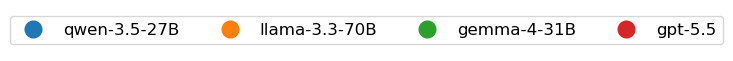

In [14]:
# Standalone shared legend for the model colors used across all plots.
os.makedirs(PLOTS_ROOT, exist_ok=True)
fig, ax = plt.subplots(figsize=(6, 0.9))
ax.axis("off")
legend_colors = [CYCLE[i % len(CYCLE)] for i in range(len(MODEL_IDS))]
ax.legend(handles=dot_handles(legend_colors, MODEL_IDS, markersize=MARKER_SIZE),
          loc="center", ncol=len(MODEL_IDS), frameon=True)
plt.savefig(f"{PLOTS_ROOT}/two_col_legend.pdf", dpi=600, bbox_inches="tight", format="pdf")
plt.tight_layout()
plt.show()

# Topic subset: dot plots (all_metrics_topic_0_3.csv)

The same mean ± 95% CI dot plots as above (evaluation measures, linguistic and
complexity features), restricted to the prompts of **one topic** from the
15-topic model. `all_metrics_topic_0_3.csv` holds one row per prompt-response
pair for the two topics that were tested statistically:

| key | dominant topic | `topic_label`                 | significance file                                          |
|-----|----------------|-------------------------------|------------------------------------------------------------|
| t0  | 0              | Business Writing & Analysis   | `../statistical_testing/all_group_differences_business.csv` |
| t3  | 3              | Travel & Diet/Meal Planning   | `../statistical_testing/all_group_differences_travel.csv`   |

Rows are averaged **per user** before bucketing, exactly as in
`../statistical_testing/statistical_testing_per_topic.ipynb`, so the figures
aggregate the same units the tests were run on. Marker fill again follows the
topic-specific `significant_fdr`. Figures and a `significance_manifest.csv`
(one line per dot, with its FDR-corrected p-value) are saved to
`../../plots/<key>/`.

[t3] Travel & Diet/Meal Planning: 179 users
ses_bucket
Low       58
Middle    74
High      47
Name: count, dtype: int64

0 / 100 measure x model tests significant after FDR



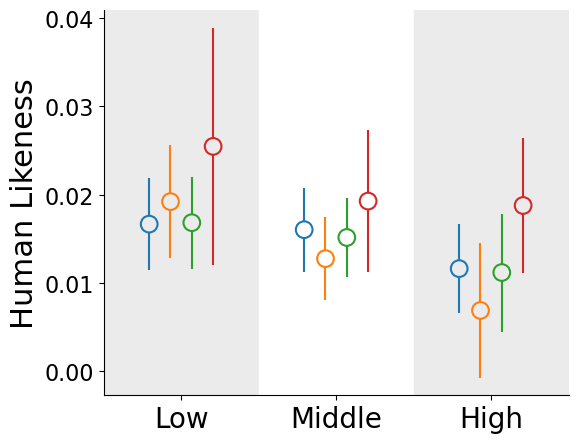

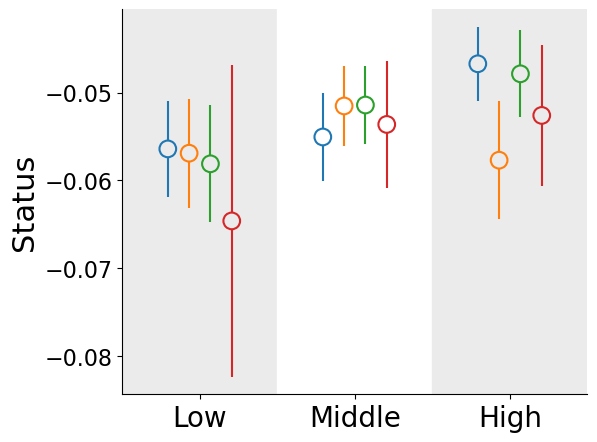

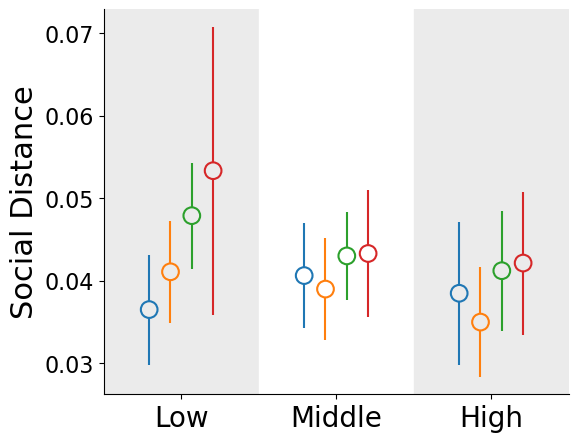

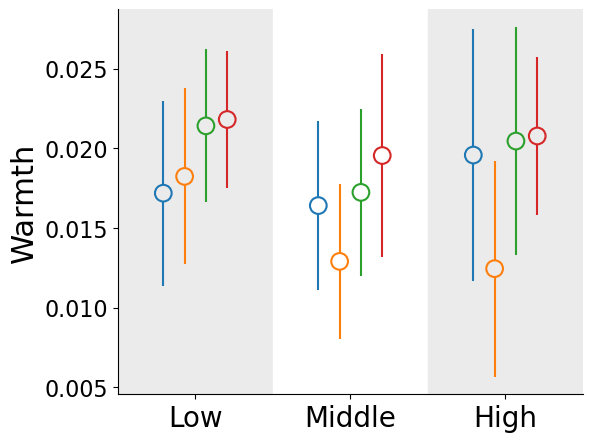

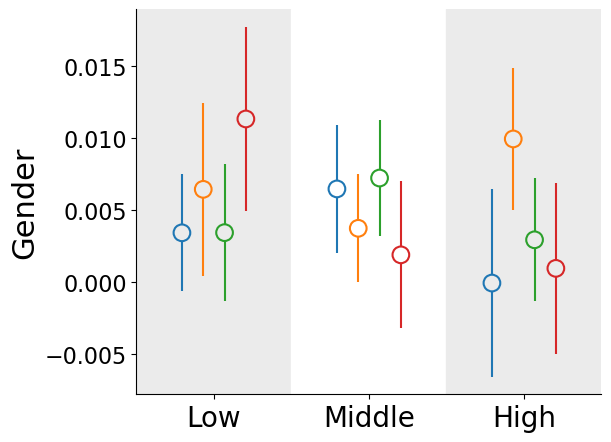

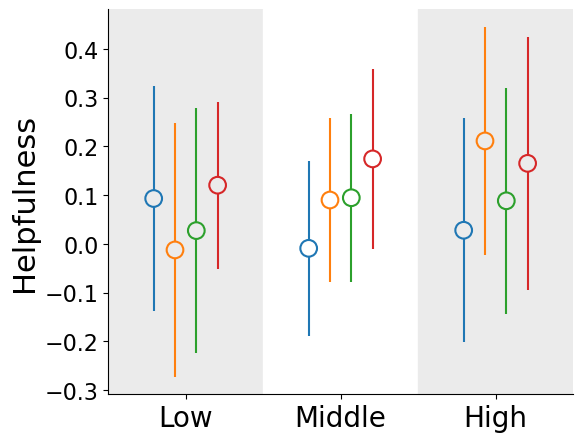

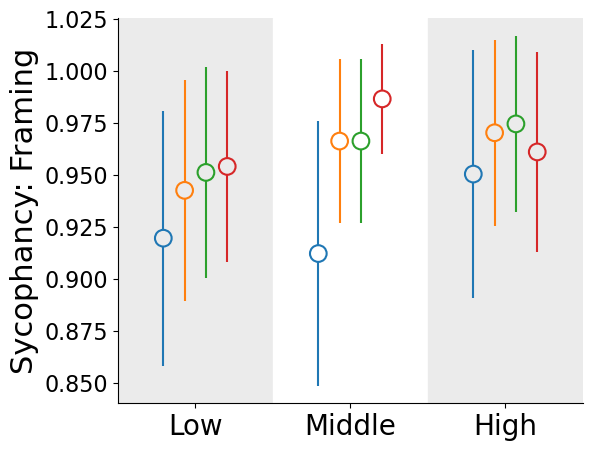

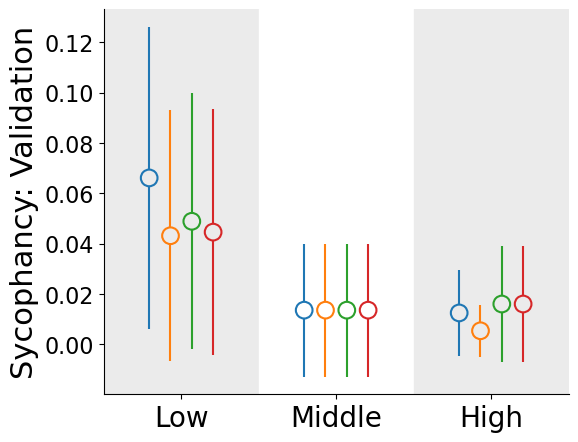

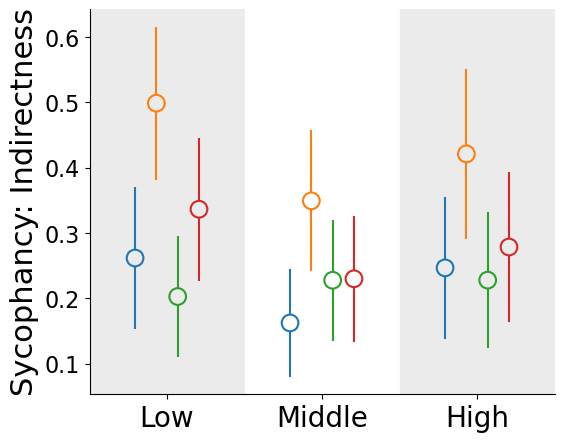

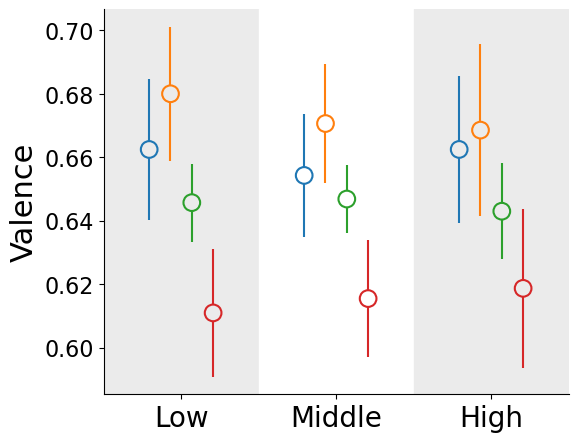

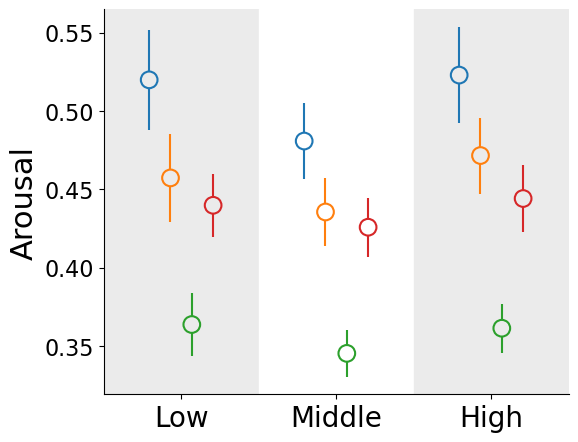

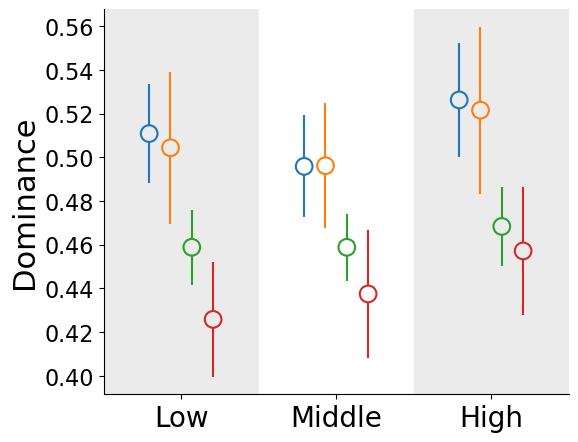

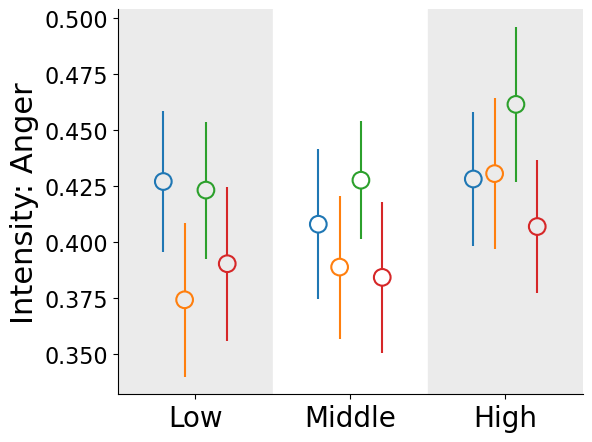

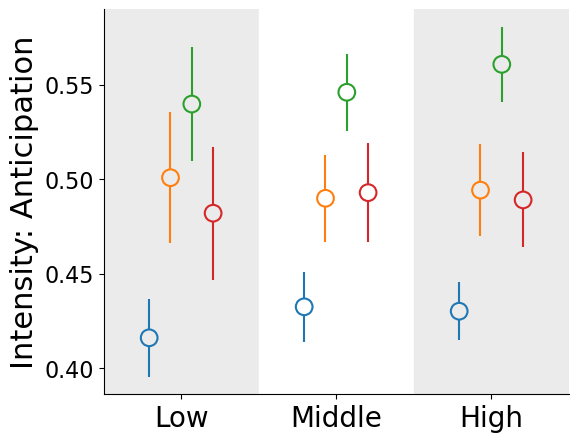

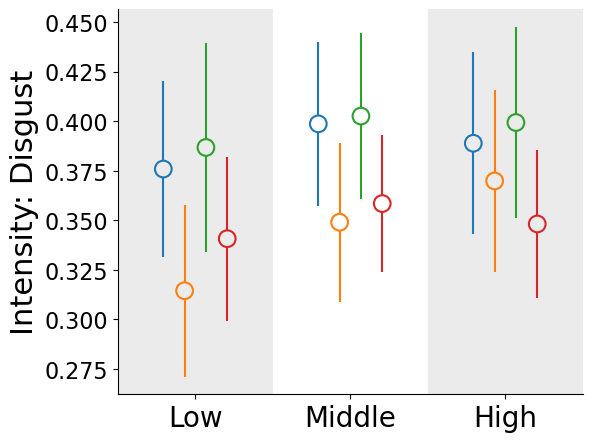

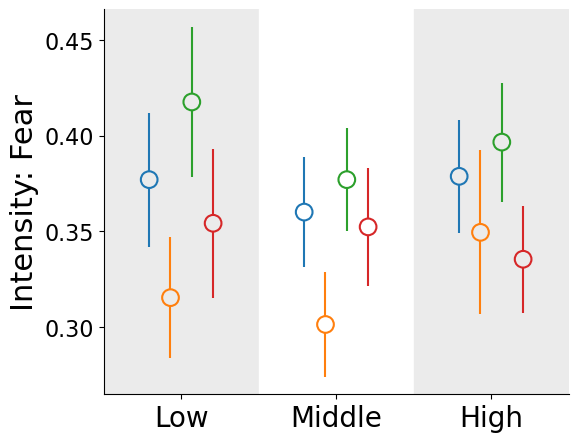

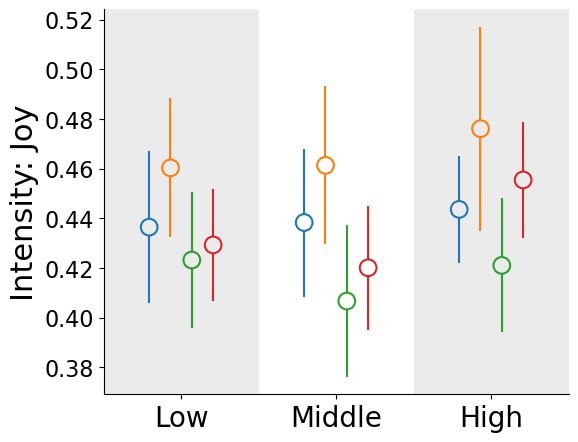

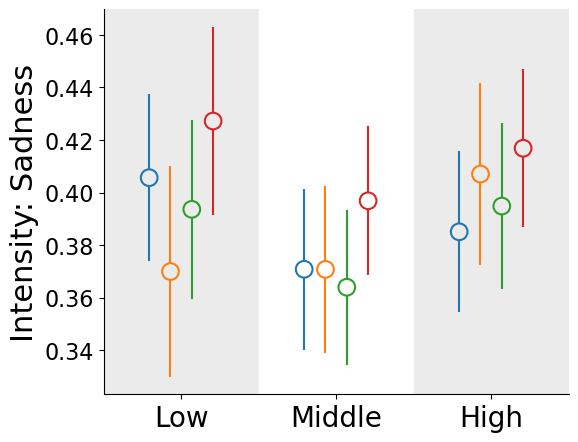

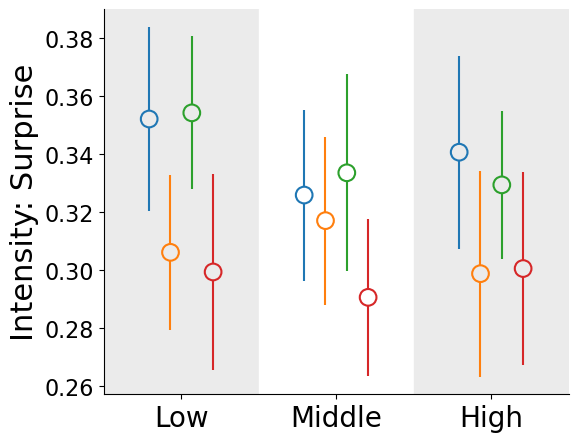

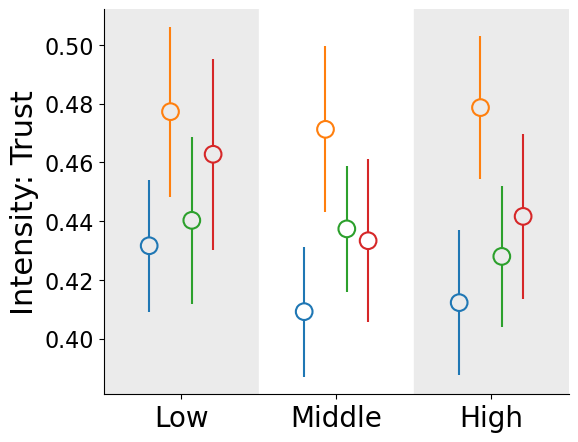

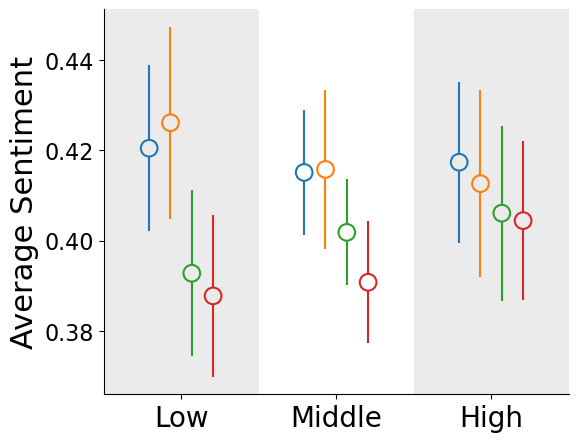

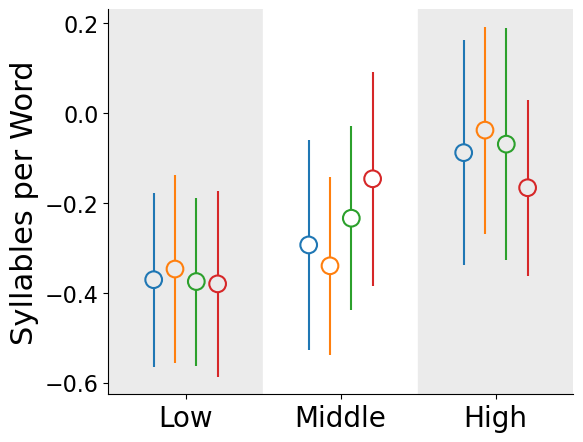

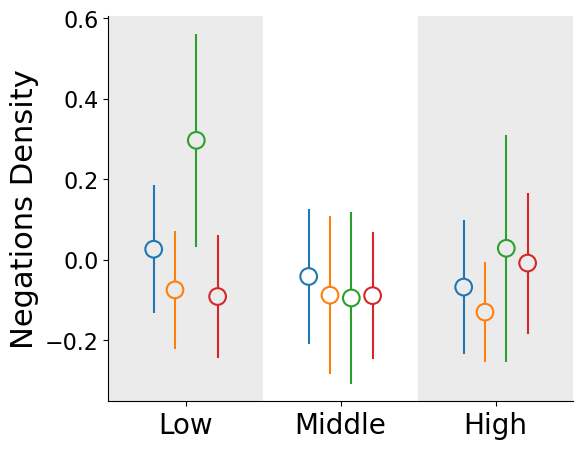

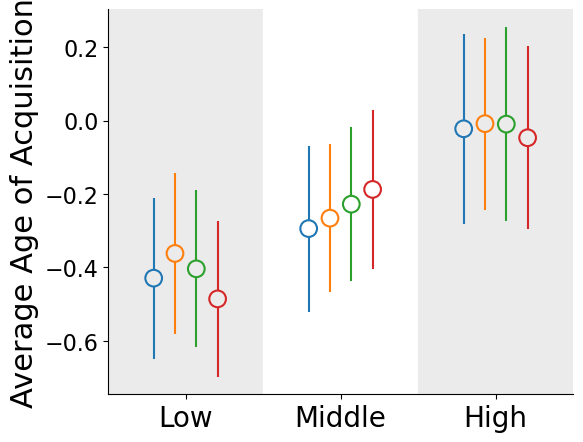

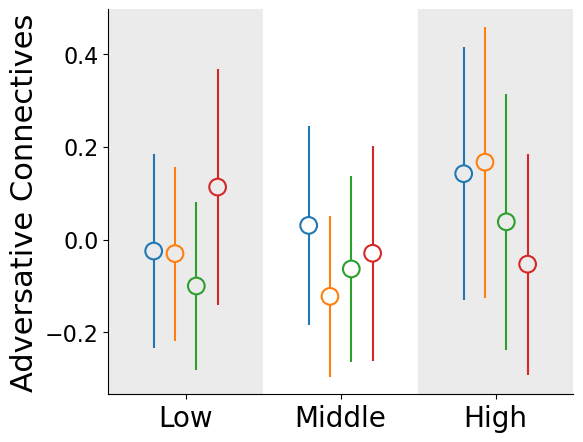

skipped (not tested / no data): ling_avg_intensity, cplx_median_kuperman_age_of_acquisition

[t3] 25 figures -> ../../plots/t3/  (0 filled / 100 dots)


,measure,column,model,p_omnibus_fdr,significant_fdr,marker


In [15]:
TOPICS = {
    "t0": ("Business Writing & Analysis", f"{STATS_DIR}/all_group_differences_business.csv"),
    "t3": ("Travel & Diet/Meal Planning", f"{STATS_DIR}/all_group_differences_travel.csv"),
}
TOPIC = "t3"           # <- pick the topic subset to plot

TOPIC_LABEL, TOPIC_STATS = TOPICS[TOPIC]
TOPIC_PLOT_DIR = f"{PLOTS_ROOT}/{TOPIC}"


def load_topic_users(topic_label):
    """Per-user rows for one topic, matching statistical_testing_per_topic.ipynb."""
    d = pd.read_csv("all_metrics_topic_0_3.csv", low_memory=False)
    d = zscore_complexity(attach_adversative(d, key="id"))   # z-score on the full 2-topic file
    d["user"] = d["id"].str.split("p").str[0]
    d = d[d["topic_label"] == topic_label]
    d = d.groupby("user", as_index=False).agg({
        "social_class": "first",
        **{c: "mean" for c in d.select_dtypes(include="number").columns},
    })
    return add_ses_bucket(d)


df_topic = load_topic_users(TOPIC_LABEL)
sig_t, p_fdr_t, tested_t = load_significance(TOPIC_STATS)

print(f"[{TOPIC}] {TOPIC_LABEL}: {len(df_topic)} users")
print(df_topic["ses_bucket"].value_counts().reindex(SES_ORDER))
print(f"\n{sum(sig_t.values())} / {len(sig_t)} measure x model tests significant after FDR\n")

manifest_topic = dot_plots(df_topic, ALL_MEASURES, sig_t, p_fdr_t, tested_t, TOPIC_PLOT_DIR)
manifest_topic.to_csv(f"{TOPIC_PLOT_DIR}/significance_manifest.csv", index=False)
print(f"\n[{TOPIC}] {manifest_topic['measure'].nunique()} figures -> {TOPIC_PLOT_DIR}/  "
      f"({int(manifest_topic.significant_fdr.sum())} filled / {len(manifest_topic)} dots)")
manifest_topic[manifest_topic.significant_fdr]